# M8 Pipeline — Pool-Anchored Huber Regression with Conformal Prediction Intervals

**Dataset:** MCC 5411 (Grocery Stores) · monthly `avg_proc_cost_pct` per merchant  
**Task:** Predict a new merchant's processing cost % for months t+1, t+2, t+3, given 1 month of context.

**Key design principle — "new merchant" framing:**  
The model never uses the target merchant's own history. All features and prediction intervals  
are derived from peer merchants only, making the pipeline applicable to merchants with no prior history.

| Section | Content |
|---|---|
| 1–3 | Imports, data, helper functions |
| 4–5 | Scenario generation, merchant-level 60/20/20 split |
| 6–7 | Pool mean feature, rolling temporal CV (architecture validation) |
| 8 | Final model fit + conformal calibration |
| 9 | End-to-end evaluation |
| 10 | Coverage level sweep |


## 1. Imports

In [1]:
import os
import math
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ── Pipeline configuration ────────────────────────────────────────────────────
CONTEXT_LEN = 3   # number of observed months fed as input to the model
HORIZON_LEN = 3   # number of months to forecast (t+1 … t+HORIZON_LEN)

# Conformal / k-NN constants
TARGET_COV  = 0.90
MIN_POOL    = 10
KNN_K       = 10


## 2. Load Data

The dataset contains monthly-aggregated payment processing cost data for MCC 5411 merchants.
Each row represents one merchant in one calendar month with the key field:
- `merchant_id` — anonymised merchant identifier
- `year`, `month` — calendar period
- `avg_proc_cost_pct` — average processing cost as a percentage of transaction value

The file should be placed in the same directory as this notebook.

In [2]:
df_5411_sample = pd.read_csv('df_5411_merchants_mthly_25th_Mar.csv')

print(f"Shape     : {df_5411_sample.shape}")
print(f"Merchants : {df_5411_sample['merchant_id'].nunique()}")
print(f"Years     : {sorted(df_5411_sample['year'].unique())}")
print()
display(df_5411_sample.head())

Shape     : (131425, 71)
Merchants : 7981
Years     : [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]



,merchant_id,year,month,transaction_count,avg_proc_cost_pct,total_processing_value,cost_type_1_pct,cost_type_2_pct,cost_type_3_pct,cost_type_4_pct,...,cost_type_56_pct,cost_type_57_pct,cost_type_58_pct,cost_type_59_pct,cost_type_60_pct,cost_type_61_pct,proc_cost_pct_lag_1,proc_cost_pct_lag_2,proc_cost_pct_lag_3,avg_transaction_value
0,5,2011,9,3,3.308678,27.060000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,9.020000
1,5,2011,11,1,4.371489,5.640000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.308678,NaN,NaN,5.640000
2,5,2012,12,9,2.213583,145.750000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.371489,3.308678,NaN,16.194444
3,20,2013,9,3,4.370629,11.349999,0.666667,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,3.783333
4,20,2014,1,1,2.499648,13.640000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.370629,NaN,NaN,13.640000


## 3. Helper Functions

- **`get_test_scenario`** — slides a (context, horizon) window over a merchant's history, returning all valid pairs with no calendar gaps.
- **`generate_pool`** — returns all peer rows dated **≤ (year, month)**, excluding the target merchant. Simulates data available at onboarding — no future leakage.
- **`find_valid_merchants`** — filters to merchants with enough months to contribute at least one scenario.


In [3]:
def get_test_scenario(df, onboard_merchant_id, context_len, context_max_NAN_months,
                      horizon_len, horizon_max_NAN_months):
    """
    Find ALL valid (context, horizon) forecast scenarios for a given merchant.

    Args:
        df                      : Monthly aggregated DataFrame with columns
                                  ['merchant_id', 'year', 'month', 'avg_proc_cost_pct']
        onboard_merchant_id     : Target merchant to enumerate scenarios for
        context_len             : Number of consecutive context months required
        context_max_NAN_months  : Max calendar gaps allowed in context window
        horizon_len             : Number of consecutive horizon months required
        horizon_max_NAN_months  : Max calendar gaps allowed in horizon window

    Returns:
        List of scenario dicts, each containing:
            context_data   : DataFrame of context period rows
            horizon_data   : DataFrame of horizon period rows
            context_range  : ((start_yr, start_mo), (end_yr, end_mo))
            horizon_range  : ((start_yr, start_mo), (end_yr, end_mo))
            context_gaps   : Number of missing calendar months in context
            horizon_gaps   : Number of missing calendar months in horizon

    [FIX] A scenario is only accepted when the horizon window starts in the
    calendar month immediately following the context window end (ctx_hor_gap == 0).
    A gap here means the merchant was inactive between context end and horizon
    start — the context data would be stale at forecast time.
    """
    merchant_data = df[df['merchant_id'] == onboard_merchant_id].copy()
    if len(merchant_data) == 0:
        return []

    merchant_data = merchant_data.sort_values(['year', 'month']).reset_index(drop=True)
    valid_scenarios = []

    for start_idx in range(len(merchant_data) - context_len - horizon_len + 1):
        context_end_idx = start_idx + context_len - 1
        context_window  = merchant_data.iloc[start_idx:context_end_idx + 1].copy().reset_index(drop=True)

        if len(context_window) > 0:
            context_start = (int(context_window.iloc[0]['year']),  int(context_window.iloc[0]['month']))
            context_end   = (int(context_window.iloc[-1]['year']), int(context_window.iloc[-1]['month']))
            expected_ctx  = (context_end[0] - context_start[0]) * 12 + (context_end[1] - context_start[1]) + 1
            nan_ctx       = expected_ctx - len(context_window)
        else:
            nan_ctx = context_len

        if nan_ctx > context_max_NAN_months or len(context_window) == 0:
            continue

        horizon_start_idx = context_end_idx + 1
        horizon_end_idx   = horizon_start_idx + horizon_len - 1

        if horizon_end_idx >= len(merchant_data):
            continue

        horizon_window = merchant_data.iloc[horizon_start_idx:horizon_end_idx + 1].copy().reset_index(drop=True)

        if len(horizon_window) > 0:
            horizon_start = (int(horizon_window.iloc[0]['year']),  int(horizon_window.iloc[0]['month']))
            horizon_end   = (int(horizon_window.iloc[-1]['year']), int(horizon_window.iloc[-1]['month']))
            expected_hor  = (horizon_end[0] - horizon_start[0]) * 12 + (horizon_end[1] - horizon_start[1]) + 1
            nan_hor       = expected_hor - len(horizon_window)
            # [FIX] Validate that horizon starts the calendar month immediately after
            # context ends.  ctx_hor_gap == 0 means adjacent months (no inactive gap).
            # ctx_hor_gap > 0 means one or more missing months between windows;
            # the merchant was inactive and the context data is stale — reject.
            ctx_hor_gap   = (horizon_start[0] - context_end[0]) * 12 + \
                             (horizon_start[1] - context_end[1]) - 1
        else:
            nan_hor     = horizon_len
            ctx_hor_gap = 999  # sentinel: no horizon data → always reject

        if nan_hor <= horizon_max_NAN_months and len(horizon_window) > 0 and ctx_hor_gap == 0:
            valid_scenarios.append({
                'context_data' : context_window,
                'horizon_data' : horizon_window,
                'context_range': (context_start, context_end),
                'horizon_range': (horizon_start, horizon_end),
                'context_gaps' : nan_ctx,
                'horizon_gaps' : nan_hor,
            })

    return valid_scenarios


In [4]:
def generate_pool(df, onboard_merchant_id, year, month):
    """
    Return the peer pool available at the time a new merchant is onboarded.

    Excludes:
      - The onboarding merchant itself
      - Any rows dated after (year, month)  — no future data leakage

    This mirrors real-world conditions: only historical peer data is visible
    at the moment of onboarding.
    """
    return df[
        (df['merchant_id'] != onboard_merchant_id) &
        ((df['year'] < year) | ((df['year'] == year) & (df['month'] <= month)))
    ].copy()

In [5]:
def find_valid_merchants(df, context_len, horizon_len, n_merchants=10, seed=42):
    """
    Return up to n_merchants IDs that have at least (context_len + horizon_len)
    months of observed data.

    Candidates are shuffled deterministically (seed) before selection so the
    result does not depend on the row order of the input DataFrame.
    """
    rng_vm     = np.random.default_rng(seed)
    min_months = context_len + horizon_len
    all_ids    = rng_vm.permutation(df['merchant_id'].unique())

    valid = []
    for mid in all_ids:
        months = df[df['merchant_id'] == mid].groupby(['year', 'month']).size()
        if len(months) >= min_months:
            valid.append(mid)
            if len(valid) >= n_merchants:
                break
    return valid


valid_merchants = find_valid_merchants(
    df_5411_sample,
    context_len=CONTEXT_LEN,
    horizon_len=HORIZON_LEN,
    n_merchants=5000,
    seed=42,
)
print(f"Merchants with ≥{CONTEXT_LEN + HORIZON_LEN} months of data: {len(valid_merchants)}")
print(f"percentage of merchants with ≥{CONTEXT_LEN + HORIZON_LEN} months of data: {len(valid_merchants) / df_5411_sample['merchant_id'].nunique():.2%}")


Merchants with ≥6 months of data: 2003
percentage of merchants with ≥6 months of data: 25.10%


## 4. Scenario Generation & Mean Baseline

Slide a `(CONTEXT_LEN, HORIZON_LEN)` window over every merchant's history. Each valid starting position becomes a training example: **`CONTEXT_LEN` observed months as input** → **`HORIZON_LEN` forecast months as target**.

Both parameters are set once in the configuration cell (cell 1) and propagated automatically through the rest of the pipeline.

**Baseline:** predict all `HORIZON_LEN` horizon months using the **mean of the context window** (flat projection). All models must beat this.


In [6]:
# Build all valid scenarios across the merchant universe
valid_test_scenarios_1 = []
for mid in valid_merchants:
    for s in get_test_scenario(
        df_5411_sample, mid,
        context_len=CONTEXT_LEN, context_max_NAN_months=0,
        horizon_len=HORIZON_LEN, horizon_max_NAN_months=0
    ):
        valid_test_scenarios_1.append({
            'merchant_id'  : mid,
            'context_data' : s['context_data'],
            'horizon_data' : s['horizon_data'],
            'context_range': s['context_range'],
            'horizon_range': s['horizon_range'],
            'context_gaps' : s['context_gaps'],
            'horizon_gaps' : s['horizon_gaps'],
        })

In [7]:
print (f"number of merchants with {CONTEXT_LEN + HORIZON_LEN} months of data: {len(valid_merchants)}")
print (f"number of merchants with valid scenarios of Context: {CONTEXT_LEN} and Horizon: {HORIZON_LEN}: {len(set(s['merchant_id'] for s in valid_test_scenarios_1))}")
print (f"percentage of merchants with valid scenarios: {len(set(s['merchant_id'] for s in valid_test_scenarios_1))/len(valid_merchants):.2%}")
print("*"*50)
print(f"Total valid scenarios (context_len={CONTEXT_LEN}, horizon_len={HORIZON_LEN}): "
      f"{len(valid_test_scenarios_1):,}")
print("*"*50)
print(f"merchant to scenario ratio: {len(valid_test_scenarios_1) / len(valid_merchants):.2f}")

number of merchants with 6 months of data: 2003
number of merchants with valid scenarios of Context: 3 and Horizon: 3: 1010
percentage of merchants with valid scenarios: 50.42%
**************************************************
Total valid scenarios (context_len=3, horizon_len=3): 84,361
**************************************************
merchant to scenario ratio: 42.12


In [8]:
# Mean baseline: predict the mean of the context window flat for all horizon steps.
baseline_maes = []
for s in valid_test_scenarios_1:
    ctx_val  = float(np.mean(s['context_data']['avg_proc_cost_pct'].values))
    hor_vals = s['horizon_data']['avg_proc_cost_pct'].values
    baseline_maes.append(float(np.mean(np.abs(hor_vals - ctx_val))))

mean_baseline_mae_1 = float(np.mean(baseline_maes))
print(f"Mean Baseline MAE (context_len={CONTEXT_LEN}, horizon_len={HORIZON_LEN}): "
      f"{mean_baseline_mae_1:.6f}")


Mean Baseline MAE (context_len=3, horizon_len=3): 1.628657


## 5. Merchant-Level 60 / 20 / 20 Split

Each scenario belongs to exactly one merchant. A naive temporal-only split would allow the same merchant to appear in both training and calibration — residuals on familiar merchants are smaller, making conformal intervals dishonestly narrow.

**Fix:** assign merchants (not scenarios) to three disjoint groups before any temporal filtering:

| Group | Role |
|---|---|
| `train_scenarios` 60% | Model training + rolling CV |
| `validate_scenarios` 20% | Conformal calibration — model never saw these merchants |
| `test_scenarios` 20% | Fully held-out evaluation |

Zero merchant ID overlap is enforced by assertion.


In [9]:
# ── Merchant-level split (seed=42 for reproducibility) ───────────────────────
rng_split = np.random.default_rng(42)

all_mids = sorted(set(s['merchant_id'] for s in valid_test_scenarios_1))
perm     = rng_split.permutation(len(all_mids))
n        = len(all_mids)

n_train = int(0.60 * n)
n_val   = int(0.20 * n)

train_mids    = set(all_mids[i] for i in perm[:n_train])
validate_mids = set(all_mids[i] for i in perm[n_train : n_train + n_val])
test_mids     = set(all_mids[i] for i in perm[n_train + n_val :])

# Partition the full scenario list by merchant group
train_scenarios    = [s for s in valid_test_scenarios_1 if s['merchant_id'] in train_mids]
validate_scenarios = [s for s in valid_test_scenarios_1 if s['merchant_id'] in validate_mids]
test_scenarios     = [s for s in valid_test_scenarios_1 if s['merchant_id'] in test_mids]

print(f"Total merchants          : {n}")
print(f"  train_mids    ({len(train_mids):3d})  60% → {len(train_scenarios):,} scenarios")
print(f"  validate_mids ({len(validate_mids):3d})  20% → {len(validate_scenarios):,} scenarios")
print(f"  test_mids     ({len(test_mids):3d})  20% → {len(test_scenarios):,} scenarios")
print()

# Sanity: zero overlap
assert not (train_mids & validate_mids), "Overlap: train ∩ validate"
assert not (train_mids & test_mids),     "Overlap: train ∩ test"
assert not (validate_mids & test_mids),  "Overlap: validate ∩ test"
print("✓ No merchant ID overlap across groups")

Total merchants          : 1010
  train_mids    (606)  60% → 51,254 scenarios
  validate_mids (202)  20% → 16,844 scenarios
  test_mids     (202)  20% → 16,263 scenarios

✓ No merchant ID overlap across groups


## 6. Pool Mean Cache

`pool_mean` — the mean `avg_proc_cost_pct` of all peer merchants with data **≤ context endpoint** — is the contemporaneous market rate at onboarding time and the primary signal in M8. Pre-computing it for every `(merchant_id, year, month)` avoids repeated pool filtering during training and inference.


In [11]:
pool_mean_cache = {}

PMC_CSV = 'pool_mean_cache_5411_25th_Mar.csv'

if os.path.exists(PMC_CSV):
    print(f"Loading pool mean cache from {PMC_CSV}...")
    pool_mean_cache_df = pd.read_csv(PMC_CSV)
    for _, row in pool_mean_cache_df.iterrows():
        pool_mean_cache[(row['merchant_id'], row['year'], row['month'])] = row['pool_mean']
    print(f"Loaded {len(pool_mean_cache):,} entries.")
else:

    unique_keys = {
        (s['merchant_id'],
        int(s['context_data'].iloc[-1]['year']),
        int(s['context_data'].iloc[-1]['month']))
        for s in valid_test_scenarios_1
    }

    print(f"Computing pool means for {len(unique_keys):,} unique (merchant, year, month) keys...")
    for mid, yr, mo in unique_keys:
        pool = generate_pool(df_5411_sample, mid, yr, mo)
        pool_mean_cache[(mid, yr, mo)] = float(pool['avg_proc_cost_pct'].mean())
    print("Done.")

    # Preview a few entries
    for k, v in list(pool_mean_cache.items())[:5]:
        print(f"  merchant={k[0]:6d}  {k[1]}-{k[2]:02d}  pool_mean={v:.4f}")

Loading pool mean cache from pool_mean_cache_5411_25th_Mar.csv...
Loaded 90,939 entries.


In [12]:
# # pool mean cache to csv

# pool_mean_cache_df = pd.DataFrame([
#     {'merchant_id': k[0], 'year': k[1], 'month': k[2], 'pool_mean': v}
#     for k, v in pool_mean_cache.items()
# ])
# pool_mean_cache_df.to_csv('pool_mean_cache_5411_25th_Mar.csv', index=False)

## 6b. k-NN Pool Mean Cache

The payment-mix fingerprint (`cost_type_{1..61}_pct`) segments merchant cost levels — merchants with similar card-type mixes tend to incur similar processing costs. A cosine k-NN lookup at each snapshot date identifies the top-10 most similar peers for a more targeted pool signal.

| Pool signal | Source | Note |
|---|---|---|
| Flat pool mean (M8) | All peers ≤ context date, equally weighted | Baseline signal |
| Cosine k-NN mean, k=10 (M9) | Top-10 by payment-mix fingerprint similarity | Targeted signal |

> **The actual improvement percentage is computed dynamically from the rolling CV in Section 7** (`avg_m9` vs `avg_m8` from `df_folds`). The fixed numbers previously shown here were stale approximations.

**k-NN pool mean is used as `pool_mean` in M9.** Query fingerprint = the context-endpoint `cost_type_*` vector; pool fingerprints = mean `cost_type_*` over all peer rows ≤ context endpoint. Fallback to flat pool mean if fewer than `KNN_K` valid neighbours exist.


In [13]:
from sklearn.neighbors import NearestNeighbors as _NNB
from collections import defaultdict as _ddict

KNN_K          = 10
COST_TYPE_COLS = [f'cost_type_{i}_pct' for i in range(1, 62)]
KNNPMC_CSV      = 'knn_pool_mean_cache_5411_25th_Mar.csv'

knn_pool_mean_cache = {}

if os.path.exists(KNNPMC_CSV):
    print(f"Loading k-NN pool mean cache from {KNNPMC_CSV}...")
    knn_pool_mean_cache_df = pd.read_csv(KNNPMC_CSV)
    for _, row in knn_pool_mean_cache_df.iterrows():
        knn_pool_mean_cache[(row['merchant_id'], row['year'], row['month'])] = row['pool_mean']
    print(f"Loaded {len(knn_pool_mean_cache):,} entries.")
else:

    # Group unique keys by snapshot date to batch fingerprint computation
    keys_by_date = _ddict(list)
    for mid, yr, mo in unique_keys:
        keys_by_date[(yr, mo)].append(mid)


    print(f"Computing k-NN pool means ({len(unique_keys):,} keys, "
        f"{len(keys_by_date)} snapshot dates, k={KNN_K}) ...")

    for (yr, mo), query_mids in sorted(keys_by_date.items()):
        # All rows up to and including this snapshot date
        snap     = df_5411_sample[
            (df_5411_sample['year'] < yr) |
            ((df_5411_sample['year'] == yr) & (df_5411_sample['month'] <= mo))
        ]
        fp_all   = snap.groupby('merchant_id')[COST_TYPE_COLS].mean()
        cost_all = snap.groupby('merchant_id')['avg_proc_cost_pct'].mean()

        if len(fp_all) < KNN_K + 1:
            for mid in query_mids:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache[(mid, yr, mo)]
            continue

        # One kNN fit per snapshot date (k+1 to allow self-exclusion)
        nn_date = _NNB(n_neighbors=min(KNN_K + 1, len(fp_all)), metric='cosine')
        nn_date.fit(fp_all.values)
        fp_index = fp_all.index.tolist()

        for mid in query_mids:
            ctx_row = df_5411_sample[
                (df_5411_sample['merchant_id'] == mid) &
                (df_5411_sample['year'] == yr) &
                (df_5411_sample['month'] == mo)
            ]
            if len(ctx_row) == 0 or mid not in fp_all.index:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache[(mid, yr, mo)]
                continue

            _, raw_idx = nn_date.kneighbors(ctx_row[COST_TYPE_COLS].values)
            top_ids    = [fp_index[i] for i in raw_idx[0] if fp_index[i] != mid][:KNN_K]

            if len(top_ids) < KNN_K:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache[(mid, yr, mo)]
            else:
                knn_pool_mean_cache[(mid, yr, mo)] = float(cost_all.loc[top_ids].mean())

    print("Done.")
    print(f"\nSample comparison (flat vs k-NN pool mean):")
    for k, v in list(knn_pool_mean_cache.items())[:5]:
        print(f"  merchant={k[0]:6d}  {k[1]}-{k[2]:02d}  "
            f"flat={pool_mean_cache[k]:.4f}  knn={v:.4f}")


Loading k-NN pool mean cache from knn_pool_mean_cache_5411_25th_Mar.csv...
Loaded 90,939 entries.


In [14]:
# # knn pool mean cache to csv

# knn_pool_mean_cache_df = pd.DataFrame([
#     {'merchant_id': k[0], 'year': k[1], 'month': k[2], 'pool_mean': v}
#     for k, v in knn_pool_mean_cache.items()
# ])
# knn_pool_mean_cache_df.to_csv('knn_pool_mean_cache_5411_25th_Mar.csv', index=False)

## 7. M8 / M9 / M10 Models — Rolling Temporal CV

Three separate `HuberRegressor` models (one per horizon step t+1, t+2, t+3) with 4 features:

| Feature / design | M8 | M9 | M10 |
|---|---|---|---|
| `context_mean` | single observed month's cost | same | same |
| `context_std` | always 0 (context_len=1) | same | same |
| `momentum` | always 0 (context_len=1) | same | same |
| `pool_mean` | flat mean of all peers ≤ context date | k-NN mean (top-10 cosine) | k-NN mean (same as M9) |
| **Training target** | `avg_proc_cost_pct` | `avg_proc_cost_pct` | `avg_proc_cost_pct − pool_mean` (deviation) |
| **Inference** | model output | model output | model output + pool_mean |

**M10 rationale:** structurally elevated years (e.g. 2018) lift both merchant costs and the peer pool mean proportionally. By training on the *deviation from pool mean*, the target variance is lower and more stable across years — the model is not distorted by market-wide cost spikes. At inference the current k-NN pool mean is added back to recover absolute cost units.

**Rolling temporal CV** validates all three architectures on `train_scenarios` only. Fold model objects are discarded; final models are fit in Section 8.


In [15]:
FEAT_NAMES_M8 = ['context_mean', 'context_std', 'momentum', 'pool_mean']


def build_features_m8(scenarios, cache):
    """Build the (N, 4) feature matrix for a list of scenarios."""
    rows = []
    for s in scenarios:
        vals   = s['context_data']['avg_proc_cost_pct'].values
        c_mean = float(np.mean(vals))
        c_std  = float(np.std(vals))
        mom    = float(vals[-1] - c_mean)
        key    = (s['merchant_id'],
                  int(s['context_data'].iloc[-1]['year']),
                  int(s['context_data'].iloc[-1]['month']))
        p_mean = cache[key]
        rows.append([c_mean, c_std, mom, p_mean])
    return np.array(rows, dtype=float)


# ── Rolling temporal CV (train_merchants only) ────────────────────────────────
_all_years = sorted({int(s['horizon_data'].iloc[0]['year']) for s in train_scenarios})
fold_cuts    = _all_years[1:]
fold_results = []

print(f"Auto-detected fold cuts: {fold_cuts}")

for cut in fold_cuts:
    train_fold = [s for s in train_scenarios
                  if int(s['horizon_data'].iloc[-1]['year']) < cut]
    test_fold  = [s for s in train_scenarios
                  if int(s['horizon_data'].iloc[0]['year']) == cut]

    if not train_fold or not test_fold:
        print(f"  Cut {cut}: skipped (train={len(train_fold)}, test={len(test_fold)})")
        continue

    y_tr_fold  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in train_fold])
    y_te_fold  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in test_fold])

    # Baseline: flat context mean projected across all horizon steps
    base_preds = np.array(
        [[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * HORIZON_LEN
         for s in test_fold]
    )
    base_mae   = float(np.mean(np.abs(y_te_fold - base_preds)))

    # ── M8: flat pool mean ─────────────────────────────────────────────────────
    X_tr_raw_m8 = build_features_m8(train_fold, pool_mean_cache)
    X_te_raw_m8 = build_features_m8(test_fold,  pool_mean_cache)
    sw_m8       = 1.0 / (X_tr_raw_m8[:, 3] + 1.0)

    scaler_m8 = StandardScaler()
    X_tr_m8   = scaler_m8.fit_transform(X_tr_raw_m8)
    X_te_m8   = scaler_m8.transform(X_te_raw_m8)

    preds_m8 = np.zeros_like(y_te_fold, dtype=float)
    for i in range(HORIZON_LEN):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr_m8, y_tr_fold[:, i], sample_weight=sw_m8)
        preds_m8[:, i] = m.predict(X_te_m8)
    m8_mae = float(np.mean(np.abs(y_te_fold - preds_m8)))

    # ── M9: k-NN pool mean ─────────────────────────────────────────────────────
    X_tr_raw_m9 = build_features_m8(train_fold, knn_pool_mean_cache)
    X_te_raw_m9 = build_features_m8(test_fold,  knn_pool_mean_cache)
    sw_m9       = 1.0 / (X_tr_raw_m9[:, 3] + 1.0)

    scaler_m9 = StandardScaler()
    X_tr_m9   = scaler_m9.fit_transform(X_tr_raw_m9)
    X_te_m9   = scaler_m9.transform(X_te_raw_m9)

    preds_m9 = np.zeros_like(y_te_fold, dtype=float)
    for i in range(HORIZON_LEN):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr_m9, y_tr_fold[:, i], sample_weight=sw_m9)
        preds_m9[:, i] = m.predict(X_te_m9)
    m9_mae = float(np.mean(np.abs(y_te_fold - preds_m9)))

    # ── M10: k-NN pool mean, deviation target ──────────────────────────────────
    X_tr_raw_m10 = build_features_m8(train_fold, knn_pool_mean_cache)
    X_te_raw_m10 = build_features_m8(test_fold,  knn_pool_mean_cache)
    sw_m10       = 1.0 / (X_tr_raw_m10[:, 3] + 1.0)

    # Deviation target: y - pool_mean (last column of X_raw)
    pool_tr_m10  = X_tr_raw_m10[:, 3]
    pool_te_m10  = X_te_raw_m10[:, 3]
    y_tr_dev     = y_tr_fold - pool_tr_m10[:, None]

    scaler_m10 = StandardScaler()
    X_tr_m10   = scaler_m10.fit_transform(X_tr_raw_m10)
    X_te_m10   = scaler_m10.transform(X_te_raw_m10)

    dev_preds_m10 = np.zeros_like(y_te_fold, dtype=float)
    for i in range(HORIZON_LEN):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr_m10, y_tr_dev[:, i], sample_weight=sw_m10)
        dev_preds_m10[:, i] = m.predict(X_te_m10)
    # Reconstruct absolute predictions
    preds_m10 = dev_preds_m10 + pool_te_m10[:, None]
    m10_mae = float(np.mean(np.abs(y_te_fold - preds_m10)))

    fold_results.append({
        'cut_year'    : cut,
        'n_train'     : len(train_fold),
        'n_test'      : len(test_fold),
        'baseline_mae': round(base_mae, 6),
        'm8_mae'      : round(m8_mae,   6),
        'm9_mae'      : round(m9_mae,   6),
        'm10_mae'     : round(m10_mae,  6),
        'm8_impr'     : round((m8_mae  - base_mae) / base_mae * 100, 2),
        'm9_impr'     : round((m9_mae  - base_mae) / base_mae * 100, 2),
        'm10_impr'    : round((m10_mae - base_mae) / base_mae * 100, 2),
    })
    print(f"  Fold {cut}: n_te={len(test_fold):,}  base={base_mae:.4f}  "
          f"M8={m8_mae:.4f} ({(m8_mae - base_mae)/base_mae*100:+.2f}%)  "
          f"M9={m9_mae:.4f} ({(m9_mae - base_mae)/base_mae*100:+.2f}%)  "
          f"M10={m10_mae:.4f} ({(m10_mae - base_mae)/base_mae*100:+.2f}%)  "
          f"{'► M10 best' if m10_mae <= min(m8_mae, m9_mae) else ('► M9 best' if m9_mae <= m8_mae else '► M8 best')}")

df_folds = pd.DataFrame(fold_results)
avg_base = df_folds['baseline_mae'].mean()
avg_m8   = df_folds['m8_mae'].mean()
avg_m9   = df_folds['m9_mae'].mean()
avg_m10  = df_folds['m10_mae'].mean()

print(f"\nRolling CV summary ({len(df_folds)} folds):")
print(f"  Avg baseline MAE : {avg_base:.6f}")
print(f"  Avg M8 MAE       : {avg_m8:.6f}  ({(avg_m8  - avg_base)/avg_base*100:+.2f}%)")
print(f"  Avg M9 MAE       : {avg_m9:.6f}  ({(avg_m9  - avg_base)/avg_base*100:+.2f}%)")
print(f"  Avg M10 MAE      : {avg_m10:.6f}  ({(avg_m10 - avg_base)/avg_base*100:+.2f}%)")
display(df_folds)


Auto-detected fold cuts: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  Fold 2011: n_te=5,218  base=1.3653  M8=1.3100 (-4.05%)  M9=1.3047 (-4.44%)  M10=1.3047 (-4.44%)  ► M10 best
  Fold 2012: n_te=5,393  base=1.2811  M8=1.2193 (-4.82%)  M9=1.2158 (-5.10%)  M10=1.2158 (-5.10%)  ► M9 best
  Fold 2013: n_te=5,358  base=1.3217  M8=1.2580 (-4.82%)  M9=1.2552 (-5.03%)  M10=1.2552 (-5.03%)  ► M10 best
  Fold 2014: n_te=5,492  base=1.4348  M8=1.3621 (-5.07%)  M9=1.3583 (-5.33%)  M10=1.3583 (-5.33%)  ► M10 best
  Fold 2015: n_te=5,619  base=1.3044  M8=1.2637 (-3.12%)  M9=1.2650 (-3.02%)  M10=1.2650 (-3.02%)  ► M8 best
  Fold 2016: n_te=5,562  base=1.3184  M8=1.2538 (-4.90%)  M9=1.2540 (-4.88%)  M10=1.2540 (-4.88%)  ► M8 best
  Fold 2017: n_te=5,535  base=1.3304  M8=1.2902 (-3.02%)  M9=1.2909 (-2.96%)  M10=1.2909 (-2.96%)  ► M8 best
  Fold 2018: n_te=5,617  base=1.3130  M8=1.2295 (-6.36%)  M9=1.2262 (-6.61%)  M10=1.2262 (-6.61%)  ► M10 best
  Fold 2019: n_te=3,712  base=1.3607  M8=1.2

,cut_year,n_train,n_test,baseline_mae,m8_mae,m9_mae,m10_mae,m8_impr,m9_impr,m10_impr
0,2011,2895,5218,1.365332,1.310039,1.304748,1.304747,-4.05,-4.44,-4.44
1,2012,8076,5393,1.281051,1.219288,1.215767,1.215767,-4.82,-5.10,-5.10
2,2013,13470,5358,1.321720,1.257972,1.255229,1.255229,-4.82,-5.03,-5.03
3,2014,18801,5492,1.434767,1.362058,1.358254,1.358253,-5.07,-5.33,-5.33
4,2015,24287,5619,1.304402,1.263738,1.264985,1.264985,-3.12,-3.02,-3.02
5,2016,29863,5562,1.318396,1.253818,1.254045,1.254048,-4.90,-4.88,-4.88
6,2017,35485,5535,1.330353,1.290189,1.290919,1.290918,-3.02,-2.96,-2.96
7,2018,40982,5617,1.313016,1.229481,1.226161,1.226161,-6.36,-6.61,-6.61
8,2019,46609,3712,1.360702,1.292566,1.292032,1.292032,-5.01,-5.05,-5.05


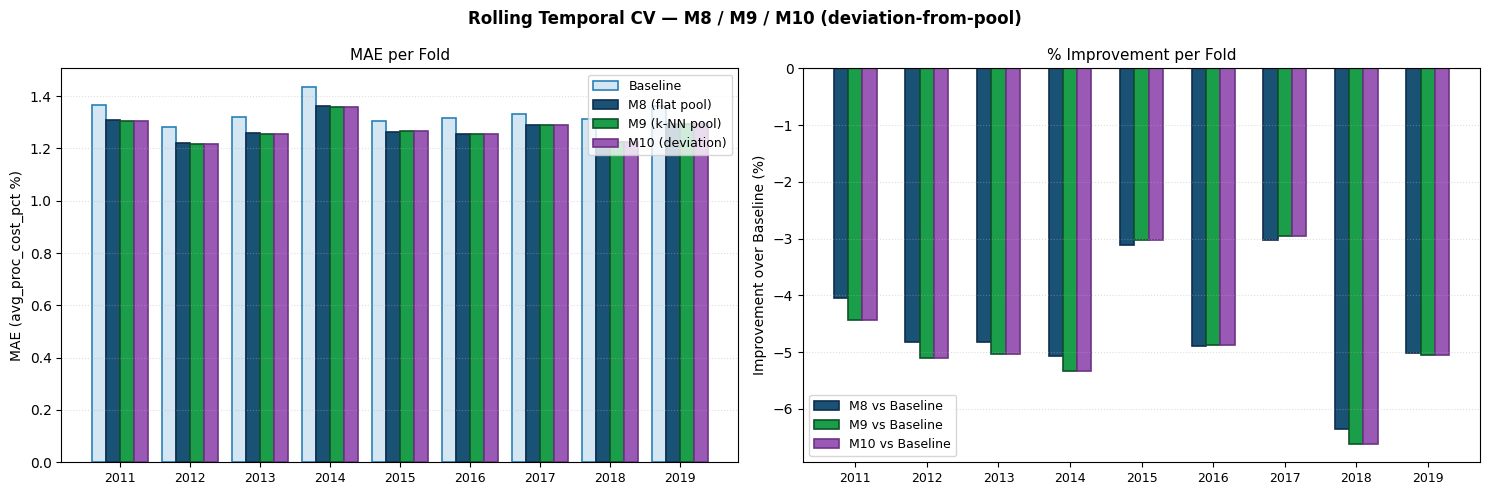

In [16]:
# Rolling CV visualisation — per-fold grouped bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Rolling Temporal CV — M8 / M9 / M10 (deviation-from-pool)', fontsize=12, fontweight='bold')

fold_labels = [str(r['cut_year']) for r in fold_results]
x           = np.arange(len(fold_labels))
bar_w       = 0.2

base_vals = [r['baseline_mae'] for r in fold_results]
m8_vals   = [r['m8_mae']       for r in fold_results]
m9_vals   = [r['m9_mae']       for r in fold_results]
m10_vals  = [r['m10_mae']      for r in fold_results]

ax1.bar(x - 1.5*bar_w, base_vals, bar_w, label='Baseline',
        color='#d4e6f1', edgecolor='#2980b9', linewidth=1.2)
ax1.bar(x - 0.5*bar_w, m8_vals,   bar_w, label='M8 (flat pool)',
        color='#1a5276', edgecolor='#0e2d4e', linewidth=1.2)
ax1.bar(x + 0.5*bar_w, m9_vals,   bar_w, label='M9 (k-NN pool)',
        color='#1a9e4a', edgecolor='#0e5228', linewidth=1.2)
ax1.bar(x + 1.5*bar_w, m10_vals,  bar_w, label='M10 (deviation)',
        color='#9b59b6', edgecolor='#6c3483', linewidth=1.2)
ax1.set_xticks(x)
ax1.set_xticklabels(fold_labels, fontsize=9)
ax1.set_ylabel('MAE (avg_proc_cost_pct %)', fontsize=10)
ax1.set_title('MAE per Fold', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle=':', alpha=0.4)

m8_impr_vals  = [r['m8_impr']  for r in fold_results]
m9_impr_vals  = [r['m9_impr']  for r in fold_results]
m10_impr_vals = [r['m10_impr'] for r in fold_results]

ax2.bar(x - bar_w,     m8_impr_vals,  bar_w, label='M8 vs Baseline',
        color='#1a5276', edgecolor='#0e2d4e', linewidth=1.2)
ax2.bar(x,             m9_impr_vals,  bar_w, label='M9 vs Baseline',
        color='#1a9e4a', edgecolor='#0e5228', linewidth=1.2)
ax2.bar(x + bar_w,     m10_impr_vals, bar_w, label='M10 vs Baseline',
        color='#9b59b6', edgecolor='#6c3483', linewidth=1.2)
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(fold_labels, fontsize=9)
ax2.set_ylabel('Improvement over Baseline (%)', fontsize=10)
ax2.set_title('% Improvement per Fold', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()


## 8. Final Models + Pool-Based Conformal Prediction Intervals

Temporal filter selects the appropriate year window from each merchant group:

| Set | Merchant group | Temporal filter | Role |
|---|---|---|---|
| `train_ci` | train (60%) | horizon < `_cal_year` | Fit M8, M9, M10 final models |
| `cal_ci` | **validate (20%)** | horizon == `_cal_year` | Calibration residuals — unseen merchants |
| `test_ci` | **test (20%)** | horizon == `_test_year` | Fully held-out evaluation |

**M8** (`models_ci` / `scaler_ci`), **M9** (`models_knn` / `scaler_knn`), and **M10** (`models_dev` / `scaler_dev`) are all fit on the same train/cal/test partition with the same Huber parameters.  M10 trains on `y − pool_mean` (deviation) and reconstructs absolute predictions at inference by adding back the current k-NN pool mean. Pool-based conformal is computed separately for each model so interval widths can be fairly compared.


In [17]:
# ── Merchant volatility classification ───────────────────────────────────────
# Volatility of a merchant's context window is measured as the Coefficient of
# Variation (CoV = std / mean). CoV is dimensionless so it is comparable across
# merchants operating at different absolute cost levels — a merchant at 1% cost
# with std 0.1 and a merchant at 10% cost with std 1.0 both have CoV=0.1.
#
# Two buckets: Low (stable) and High (volatile) split at a single CoV threshold.
# Run the threshold-sweep cell to find the optimal cut, then update VOL_THRESHOLD.

_VOL_EPS       = 1e-6   # guard against zero division for near-constant series
VOL_THRESHOLD  = 0.15   # ← tune this: Low = CoV < threshold, High = CoV ≥ threshold
N_VOL_BINS     = 2
VOL_LABELS     = ['Low', 'High']


def ctx_cov(scenario):
    """Coefficient of Variation of the merchant's context cost window."""
    v = scenario['context_data']['avg_proc_cost_pct'].values.astype(float)
    return float(np.std(v) / (np.abs(np.mean(v)) + _VOL_EPS))


In [18]:
# Cal/test years derived dynamically
_ci_years  = sorted({int(s['horizon_data'].iloc[0]['year']) for s in valid_test_scenarios_1})
_cal_year  = _ci_years[-2]
_test_year = _ci_years[-1]

print(f"cal_year={_cal_year}  test_year={_test_year}")

# ── Temporal filter on merchant groups ────────────────────────────────────────
# Use horizon start (iloc[0]) as the cut boundary so that scenarios whose
# horizon begins before _cal_year are retained even if the last step spills in.
train_ci = [s for s in train_scenarios
            if int(s['horizon_data'].iloc[0]['year']) < _cal_year]
cal_ci   = [s for s in validate_scenarios
            if int(s['horizon_data'].iloc[0]['year']) == _cal_year]
test_ci  = [s for s in test_scenarios
            if int(s['horizon_data'].iloc[0]['year']) == _test_year]

print(f"train_ci={len(train_ci):,}  cal_ci={len(cal_ci):,}  test_ci={len(test_ci):,}")

# Common targets
y_tr  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in train_ci])
y_cal = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in cal_ci])
y_te  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in test_ci])

# ── M8: flat pool mean ─────────────────────────────────────────────────────────
X_tr_raw  = build_features_m8(train_ci, pool_mean_cache)
X_cal_raw = build_features_m8(cal_ci,   pool_mean_cache)
X_te_raw  = build_features_m8(test_ci,  pool_mean_cache)
sw        = 1.0 / (X_tr_raw[:, 3] + 1.0)

scaler_ci = StandardScaler()
X_tr  = scaler_ci.fit_transform(X_tr_raw)
X_cal = scaler_ci.transform(X_cal_raw)
X_te  = scaler_ci.transform(X_te_raw)

cal_preds = np.zeros_like(y_cal, dtype=float)
te_preds  = np.zeros_like(y_te,  dtype=float)
models_ci = []

for h in range(HORIZON_LEN):
    m = HuberRegressor(epsilon=1.35, max_iter=500)
    m.fit(X_tr, y_tr[:, h], sample_weight=sw)
    cal_preds[:, h] = m.predict(X_cal)
    te_preds[:, h]  = m.predict(X_te)
    models_ci.append(m)

cal_max_res_raw = np.abs(y_cal - cal_preds).max(axis=1)
q90_global      = float(np.quantile(cal_max_res_raw, 0.90))
print(f"\nM8: q90_global=±{q90_global:.4f}  "
      f"range=[{cal_max_res_raw.min():.4f}, {cal_max_res_raw.max():.4f}]")

# ── M9: k-NN pool mean ─────────────────────────────────────────────────────────
X_tr_knn_raw  = build_features_m8(train_ci, knn_pool_mean_cache)
X_cal_knn_raw = build_features_m8(cal_ci,   knn_pool_mean_cache)
X_te_knn_raw  = build_features_m8(test_ci,  knn_pool_mean_cache)
sw_knn        = 1.0 / (X_tr_knn_raw[:, 3] + 1.0)

scaler_knn = StandardScaler()
X_tr_knn  = scaler_knn.fit_transform(X_tr_knn_raw)
X_cal_knn = scaler_knn.transform(X_cal_knn_raw)
X_te_knn  = scaler_knn.transform(X_te_knn_raw)

cal_preds_knn = np.zeros_like(y_cal, dtype=float)
te_preds_knn  = np.zeros_like(y_te,  dtype=float)
models_knn    = []

for h in range(HORIZON_LEN):
    m = HuberRegressor(epsilon=1.35, max_iter=500)
    m.fit(X_tr_knn, y_tr[:, h], sample_weight=sw_knn)
    cal_preds_knn[:, h] = m.predict(X_cal_knn)
    te_preds_knn[:, h]  = m.predict(X_te_knn)
    models_knn.append(m)

cal_max_res_knn = np.abs(y_cal - cal_preds_knn).max(axis=1)
q90_global_knn  = float(np.quantile(cal_max_res_knn, 0.90))
print(f"M9: q90_global_knn=±{q90_global_knn:.4f}  "
      f"range=[{cal_max_res_knn.min():.4f}, {cal_max_res_knn.max():.4f}]")

# ── M10: k-NN pool mean, deviation target ─────────────────────────────────────
X_tr_dev_raw  = build_features_m8(train_ci, knn_pool_mean_cache)
X_cal_dev_raw = build_features_m8(cal_ci,   knn_pool_mean_cache)
X_te_dev_raw  = build_features_m8(test_ci,  knn_pool_mean_cache)
sw_dev        = 1.0 / (X_tr_dev_raw[:, 3] + 1.0)

pool_tr_dev   = X_tr_dev_raw[:, 3]
pool_cal_dev  = X_cal_dev_raw[:, 3]
pool_te_dev   = X_te_dev_raw[:, 3]

# Deviation targets
y_tr_dev_m10  = y_tr  - pool_tr_dev[:, None]
y_cal_dev_m10 = y_cal - pool_cal_dev[:, None]

scaler_dev = StandardScaler()
X_tr_dev  = scaler_dev.fit_transform(X_tr_dev_raw)
X_cal_dev = scaler_dev.transform(X_cal_dev_raw)
X_te_dev  = scaler_dev.transform(X_te_dev_raw)

cal_dev_preds = np.zeros_like(y_cal, dtype=float)
te_dev_preds  = np.zeros_like(y_te,  dtype=float)
models_dev    = []

for h in range(HORIZON_LEN):
    m = HuberRegressor(epsilon=1.35, max_iter=500)
    m.fit(X_tr_dev, y_tr_dev_m10[:, h], sample_weight=sw_dev)
    cal_dev_preds[:, h] = m.predict(X_cal_dev)
    te_dev_preds[:, h]  = m.predict(X_te_dev)
    models_dev.append(m)

# Reconstruct absolute predictions
cal_preds_dev = cal_dev_preds + pool_cal_dev[:, None]
te_preds_dev  = te_dev_preds  + pool_te_dev[:, None]

cal_max_res_dev = np.abs(y_cal - cal_preds_dev).max(axis=1)
q90_global_dev  = float(np.quantile(cal_max_res_dev, 0.90))
print(f"M10: q90_global_dev=±{q90_global_dev:.4f}  "
      f"range=[{cal_max_res_dev.min():.4f}, {cal_max_res_dev.max():.4f}]")


cal_year=2018  test_year=2019
train_ci=41,925  cal_ci=1,841  test_ci=1,183

M8: q90_global=±5.4847  range=[0.0285, 265.7198]
M9: q90_global_knn=±5.4739  range=[0.0275, 265.0555]
M10: q90_global_dev=±5.4739  range=[0.0275, 265.0546]


In [19]:
TARGET_COV = 0.90
MIN_POOL   = 10


def adaptive_q(residuals, target=TARGET_COV):
    """Finite-sample conformal quantile at level ceil((n+1)*target)/n."""
    n     = len(residuals)
    level = math.ceil((n + 1) * target) / n
    return float(np.quantile(residuals, level)) if level <= 1.0 else None


# ── M8 conformal ──────────────────────────────────────────────────────────────
cal_merchant_ids = np.array([s['merchant_id'] for s in cal_ci])
merchant_cal_res = defaultdict(list)
for i, res in enumerate(cal_max_res_raw):
    merchant_cal_res[int(cal_merchant_ids[i])].append(float(res))

print(f"Cal merchants: {len(merchant_cal_res)}  "
      f"total residuals: {sum(len(v) for v in merchant_cal_res.values())}")

hw_per_scenario = np.zeros(len(test_ci))
pool_cal_sizes  = []
pool_stats      = {'local': 0, 'global_fallback': 0}

for i, s in enumerate(test_ci):
    yr, mo    = s['context_range'][1]
    peer_mids = set(int(p) for p in
                    generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
    peer_res  = [r for peer in peer_mids for r in merchant_cal_res.get(peer, [])]
    pool_cal_sizes.append(len(peer_res))

    q_local = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
    if q_local is not None:
        hw_per_scenario[i] = q_local
        pool_stats['local'] += 1
    else:
        hw_per_scenario[i] = q90_global
        pool_stats['global_fallback'] += 1

lo_pool = np.clip(te_preds - hw_per_scenario[:, None], 0, None)
hi_pool = te_preds + hw_per_scenario[:, None]

in_pool    = (y_te >= lo_pool) & (y_te <= hi_pool)
joint_pool = float(np.mean(in_pool.all(axis=1)))
marg_pool  = float(np.mean(in_pool))
width_pool = float(np.mean(hi_pool - lo_pool))

print(f"\nM8 conformal @ {TARGET_COV*100:.0f}%  "
      f"local={pool_stats['local']} ({pool_stats['local']/len(test_ci)*100:.0f}%)  "
      f"fallback={pool_stats['global_fallback']}")
print(f"  joint={joint_pool:.3f}  marginal={marg_pool:.3f}  "
      f"avg half-width=±{width_pool/2:.4f}  (global ±{q90_global:.4f})")

# ── M9 conformal ──────────────────────────────────────────────────────────────
merchant_cal_res_knn = defaultdict(list)
for i, res in enumerate(cal_max_res_knn):
    merchant_cal_res_knn[int(cal_merchant_ids[i])].append(float(res))

hw_per_scenario_knn = np.zeros(len(test_ci))
pool_stats_knn      = {'local': 0, 'global_fallback': 0}

for i, s in enumerate(test_ci):
    yr, mo    = s['context_range'][1]
    peer_mids = set(int(p) for p in
                    generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
    peer_res  = [r for peer in peer_mids for r in merchant_cal_res_knn.get(peer, [])]

    q_local = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
    if q_local is not None:
        hw_per_scenario_knn[i] = q_local
        pool_stats_knn['local'] += 1
    else:
        hw_per_scenario_knn[i] = q90_global_knn
        pool_stats_knn['global_fallback'] += 1

lo_pool_knn = np.clip(te_preds_knn - hw_per_scenario_knn[:, None], 0, None)
hi_pool_knn = te_preds_knn + hw_per_scenario_knn[:, None]

in_pool_knn    = (y_te >= lo_pool_knn) & (y_te <= hi_pool_knn)
joint_pool_knn = float(np.mean(in_pool_knn.all(axis=1)))
marg_pool_knn  = float(np.mean(in_pool_knn))
width_pool_knn = float(np.mean(hi_pool_knn - lo_pool_knn))

print(f"\nM9 conformal @ {TARGET_COV*100:.0f}%  "
      f"local={pool_stats_knn['local']} ({pool_stats_knn['local']/len(test_ci)*100:.0f}%)  "
      f"fallback={pool_stats_knn['global_fallback']}")
print(f"  joint={joint_pool_knn:.3f}  marginal={marg_pool_knn:.3f}  "
      f"avg half-width=±{width_pool_knn/2:.4f}  (global ±{q90_global_knn:.4f})")

# ── M10 conformal ─────────────────────────────────────────────────────────────
merchant_cal_res_dev = defaultdict(list)
for i, res in enumerate(cal_max_res_dev):
    merchant_cal_res_dev[int(cal_merchant_ids[i])].append(float(res))

hw_per_scenario_dev = np.zeros(len(test_ci))
pool_stats_dev      = {'local': 0, 'global_fallback': 0}

for i, s in enumerate(test_ci):
    yr, mo    = s['context_range'][1]
    peer_mids = set(int(p) for p in
                    generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
    peer_res  = [r for peer in peer_mids for r in merchant_cal_res_dev.get(peer, [])]

    q_local = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
    if q_local is not None:
        hw_per_scenario_dev[i] = q_local
        pool_stats_dev['local'] += 1
    else:
        hw_per_scenario_dev[i] = q90_global_dev
        pool_stats_dev['global_fallback'] += 1

lo_pool_dev = np.clip(te_preds_dev - hw_per_scenario_dev[:, None], 0, None)
hi_pool_dev = te_preds_dev + hw_per_scenario_dev[:, None]

in_pool_dev    = (y_te >= lo_pool_dev) & (y_te <= hi_pool_dev)
joint_pool_dev = float(np.mean(in_pool_dev.all(axis=1)))
marg_pool_dev  = float(np.mean(in_pool_dev))
width_pool_dev = float(np.mean(hi_pool_dev - lo_pool_dev))

print(f"\nM10 conformal @ {TARGET_COV*100:.0f}%  "
      f"local={pool_stats_dev['local']} ({pool_stats_dev['local']/len(test_ci)*100:.0f}%)  "
      f"fallback={pool_stats_dev['global_fallback']}")
print(f"  joint={joint_pool_dev:.3f}  marginal={marg_pool_dev:.3f}  "
      f"avg half-width=±{width_pool_dev/2:.4f}  (global ±{q90_global_dev:.4f})")

# ── Side-by-side summary ───────────────────────────────────────────────────────
print(f"\n{'─'*64}")
print(f"{'Metric':<28}  {'M8 (flat)':>10}  {'M9 (k-NN)':>10}  {'M10 (dev)':>10}")
print(f"{'─'*64}")
print(f"{'Joint coverage':<28}  {joint_pool:>10.3f}  {joint_pool_knn:>10.3f}  {joint_pool_dev:>10.3f}")
print(f"{'Marginal coverage':<28}  {marg_pool:>10.3f}  {marg_pool_knn:>10.3f}  {marg_pool_dev:>10.3f}")
print(f"{'Avg half-width (pp)':<28}  {width_pool/2:>10.4f}  {width_pool_knn/2:>10.4f}  {width_pool_dev/2:>10.4f}")
print(f"{'─'*64}")


Cal merchants: 182  total residuals: 1841

M8 conformal @ 90%  local=1183 (100%)  fallback=0
  joint=0.934  marginal=0.970  avg half-width=±4.5202  (global ±5.4847)

M9 conformal @ 90%  local=1183 (100%)  fallback=0
  joint=0.934  marginal=0.970  avg half-width=±4.5077  (global ±5.4739)

M10 conformal @ 90%  local=1183 (100%)  fallback=0
  joint=0.934  marginal=0.970  avg half-width=±4.5077  (global ±5.4739)

────────────────────────────────────────────────────────────────
Metric                         M8 (flat)   M9 (k-NN)   M10 (dev)
────────────────────────────────────────────────────────────────
Joint coverage                     0.934       0.934       0.934
Marginal coverage                  0.970       0.970       0.970
Avg half-width (pp)               4.5202      4.5077      4.5077
────────────────────────────────────────────────────────────────


## 11. Volatility-Stratified Conformal Intervals

The global conformal quantile (`q90_global`) pools residuals from all merchants regardless of how stable or volatile they are. Low-volatility merchants have small residuals and end up over-covered (unnecessarily wide CI); high-volatility merchants may be under-covered if their residuals dominate the tail.

**Stratification approach:** merchants are split into exactly **two** regimes — **Low** (stable) and **High** (volatile) — using a single CoV threshold on the context window. A separate conformal q90 is estimated from calibration residuals in each bucket; test scenarios inherit the quantile of their matching bucket. The threshold is chosen via a sweep that minimises average half-width while maintaining the joint coverage target.

| Concept | Detail |
|---|---|
| **Volatility signal** | CoV of context window  `= std(ctx) / mean(ctx)` |
| **Buckets** | Low (CoV < `VOL_THRESHOLD`) and High (CoV ≥ `VOL_THRESHOLD`) |
| **Threshold tuning** | Sweep in the computation cell; update `VOL_THRESHOLD` in the helper cell |
| **Per-bucket q90** | `adaptive_q` on cal residuals in that bucket; falls back to global if n < `MIN_POOL` |
| **Coverage guarantee** | Each bucket independently maintains the conformal validity guarantee |
| **Expected outcome** | Low merchants get a tighter CI; High merchants get a wider, properly calibrated CI |


In [20]:
# ── 1. Compute context CoV for calibration and test scenarios ─────────────────
cal_cv = np.array([ctx_cov(s) for s in cal_ci])
te_cv  = np.array([ctx_cov(s) for s in test_ci])

# ── 2. Threshold sweep — tune the Low | High CoV split ────────────────────────
# For each candidate threshold, compute 2-bucket q90s and evaluate avg half-width
# and joint coverage on the test set (M9).  The recommended threshold is the one
# that minimises avg_hw while keeping joint_cov >= TARGET_COV.
# Update VOL_THRESHOLD in the helper cell to use a different value.

THRESH_CANDIDATES = [0.04, 0.06, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]

def _eval_threshold(thr):
    """Return (avg_hw, joint_cov, n_low, n_high) for M9 at a given CoV split."""
    cal_b = (cal_cv >= thr).astype(int)
    te_b  = (te_cv  >= thr).astype(int)
    bq = {}
    for b in [0, 1]:
        res_b = cal_max_res_knn[cal_b == b].tolist()
        bq[b] = adaptive_q(res_b) if len(res_b) >= MIN_POOL else q90_global_knn
    hw  = np.array([bq[b] for b in te_b])
    lo  = np.clip(te_preds_knn - hw[:, None], 0, None)
    hi  = te_preds_knn + hw[:, None]
    in_ = (y_te >= lo) & (y_te <= hi)
    return float(np.mean(hw)), float(np.mean(in_.all(axis=1))), int((te_b == 0).sum()), int((te_b == 1).sum())

print(f"{'─'*76}")
print(f"Threshold sweep — 2-bucket Low / High  (M9 k-NN, test set)")
print(f"  {'Threshold':>9}  {'n_Low':>6}  {'n_High':>7}  {'avg_hw':>9}  {'joint_cov':>11}  status")
print(f"{'─'*76}")
_best_thr, _best_hw = VOL_THRESHOLD, float('inf')
for thr in THRESH_CANDIDATES:
    hw_t, cov_t, nl, nh = _eval_threshold(thr)
    ok   = cov_t >= TARGET_COV
    flag = '✓ covered' if ok else '✗ under-cov'
    star = '  ◀ best so far' if ok and hw_t < _best_hw else ''
    print(f"  CoV {thr:.2f}    {nl:>6}  {nh:>7}  {hw_t:>9.4f}  {cov_t:>11.3f}  {flag}{star}")
    if ok and hw_t < _best_hw:
        _best_hw, _best_thr = hw_t, thr
print(f"{'─'*76}")
print(f"\n  ▶ Recommended (min hw, joint_cov ≥ {TARGET_COV:.0%}): CoV threshold = {_best_thr:.2f}")
if _best_thr != VOL_THRESHOLD:
    print(f"    Current VOL_THRESHOLD={VOL_THRESHOLD:.2f} — update the helper cell to {_best_thr:.2f} for tighter CIs.")
else:
    print(f"    VOL_THRESHOLD={VOL_THRESHOLD:.2f} is already optimal.")

# ── 3. Assign 2-bucket bins using VOL_THRESHOLD ───────────────────────────────
def assign_vol_bin(cv_val):
    return 0 if cv_val < VOL_THRESHOLD else 1   # 0 = Low, 1 = High

cal_vol_bins = np.array([assign_vol_bin(v) for v in cal_cv])
te_vol_bins  = np.array([assign_vol_bin(v) for v in te_cv])

print(f"\nBucket population  (threshold CoV = {VOL_THRESHOLD:.2f}):")
for b, lbl in enumerate(VOL_LABELS):
    print(f"  {lbl:<6}: cal={np.sum(cal_vol_bins == b):4d}  test={np.sum(te_vol_bins == b):4d}")

# ── 4. Per-bucket conformal quantile from cal residuals ───────────────────────
q90_strat = {}   # {'M8': {0: q_low, 1: q_high}, 'M9': ..., 'M10': ...}

for mlabel, cal_res, q90_fallback in [
    ('M8',  cal_max_res_raw, q90_global),
    ('M9',  cal_max_res_knn, q90_global_knn),
    ('M10', cal_max_res_dev, q90_global_dev),
]:
    bq = {}
    print(f"\n{mlabel} — stratified q90:")
    for b, lbl in enumerate(VOL_LABELS):
        mask_b = cal_vol_bins == b
        res_b  = cal_res[mask_b].tolist()
        q = adaptive_q(res_b) if len(res_b) >= MIN_POOL else None
        bq[b] = q if q is not None else q90_fallback
        print(f"  {lbl:<6}: n_cal={mask_b.sum():4d}  q90=±{bq[b]:.4f}  "
              f"(global=±{q90_fallback:.4f}  Δ={bq[b] - q90_fallback:+.4f})")
    q90_strat[mlabel] = bq

# ── 5. Build stratified intervals ─────────────────────────────────────────────
hw_strat_m8  = np.array([q90_strat['M8'][b]  for b in te_vol_bins])
hw_strat_m9  = np.array([q90_strat['M9'][b]  for b in te_vol_bins])
hw_strat_m10 = np.array([q90_strat['M10'][b] for b in te_vol_bins])

lo_strat_m8  = np.clip(te_preds     - hw_strat_m8[:,  None], 0, None)
hi_strat_m8  = te_preds     + hw_strat_m8[:,  None]
lo_strat_m9  = np.clip(te_preds_knn - hw_strat_m9[:,  None], 0, None)
hi_strat_m9  = te_preds_knn + hw_strat_m9[:,  None]
lo_strat_m10 = np.clip(te_preds_dev - hw_strat_m10[:, None], 0, None)
hi_strat_m10 = te_preds_dev + hw_strat_m10[:, None]

# ── 6. Overall coverage and width summary ─────────────────────────────────────
strat_results = {}
print(f"\n{'─'*70}")
print(f"{'Model':<6}  {'Joint Global':>13}  {'Joint Strat':>12}  "
      f"{'hw Global':>10}  {'hw Strat':>10}  {'Δhw':>8}")
print(f"{'─'*70}")

for mlabel, lo_g, hi_g, lo_s, hi_s, hw_s, w_pool_g in [
    ('M8',  lo_pool,     hi_pool,     lo_strat_m8,  hi_strat_m8,  hw_strat_m8,  width_pool),
    ('M9',  lo_pool_knn, hi_pool_knn, lo_strat_m9,  hi_strat_m9,  hw_strat_m9,  width_pool_knn),
    ('M10', lo_pool_dev, hi_pool_dev, lo_strat_m10, hi_strat_m10, hw_strat_m10, width_pool_dev),
]:
    in_g = (y_te >= lo_g) & (y_te <= hi_g)
    in_s = (y_te >= lo_s) & (y_te <= hi_s)

    joint_g  = float(np.mean(in_g.all(axis=1)))
    joint_s  = float(np.mean(in_s.all(axis=1)))
    avg_hw_g = w_pool_g / 2
    avg_hw_s = float(np.mean(hw_s))
    delta_hw = avg_hw_s - avg_hw_g

    strat_results[mlabel] = dict(
        joint_g=joint_g, joint_s=joint_s,
        hw_g=avg_hw_g,   hw_s=avg_hw_s,
        delta_hw=delta_hw,
    )
    direction = '▼ narrower' if delta_hw < 0 else '▲ wider'
    print(f"{mlabel:<6}  {joint_g:>13.3f}  {joint_s:>12.3f}  "
          f"{avg_hw_g:>10.4f}  {avg_hw_s:>10.4f}  {delta_hw:>+8.4f}  {direction}")

print(f"{'─'*70}")

# ── 7. Per-bucket coverage breakdown (all models) ─────────────────────────────
print(f"\nPer-bucket coverage on test set  (target = {TARGET_COV:.0%}):")
for mlabel, lo_s, hi_s, hw_s in [
    ('M8',  lo_strat_m8,  hi_strat_m8,  hw_strat_m8),
    ('M9',  lo_strat_m9,  hi_strat_m9,  hw_strat_m9),
    ('M10', lo_strat_m10, hi_strat_m10, hw_strat_m10),
]:
    print(f"\n  {mlabel}:")
    for b, lbl in enumerate(VOL_LABELS):
        mask_b = te_vol_bins == b
        if mask_b.sum() == 0:
            continue
        in_b = (y_te[mask_b] >= lo_s[mask_b]) & (y_te[mask_b] <= hi_s[mask_b])
        jt   = float(np.mean(in_b.all(axis=1)))
        mg   = float(np.mean(in_b))
        flag = '✓' if jt >= TARGET_COV else '✗'
        print(f"    {flag} {lbl:<6}: n={mask_b.sum():4d}  joint={jt:.3f}  "
              f"marginal={mg:.3f}  avg hw=±{hw_s[mask_b].mean():.4f}")

────────────────────────────────────────────────────────────────────────────
Threshold sweep — 2-bucket Low / High  (M9 k-NN, test set)
  Threshold   n_Low   n_High     avg_hw    joint_cov  status
────────────────────────────────────────────────────────────────────────────
  CoV 0.04        78     1105     5.4735        0.926  ✓ covered  ◀ best so far
  CoV 0.06       158     1025     5.4953        0.923  ✓ covered
  CoV 0.08       255      928     5.6099        0.923  ✓ covered
  CoV 0.10       350      833     5.5262        0.921  ✓ covered
  CoV 0.12       457      726     5.3627        0.925  ✓ covered  ◀ best so far
  CoV 0.15       581      602     5.5000        0.930  ✓ covered
  CoV 0.20       779      404     5.2533        0.930  ✓ covered  ◀ best so far
  CoV 0.25       905      278     5.4874        0.932  ✓ covered
  CoV 0.30      1002      181     5.3951        0.926  ✓ covered
────────────────────────────────────────────────────────────────────────────

  ▶ Recommended (m

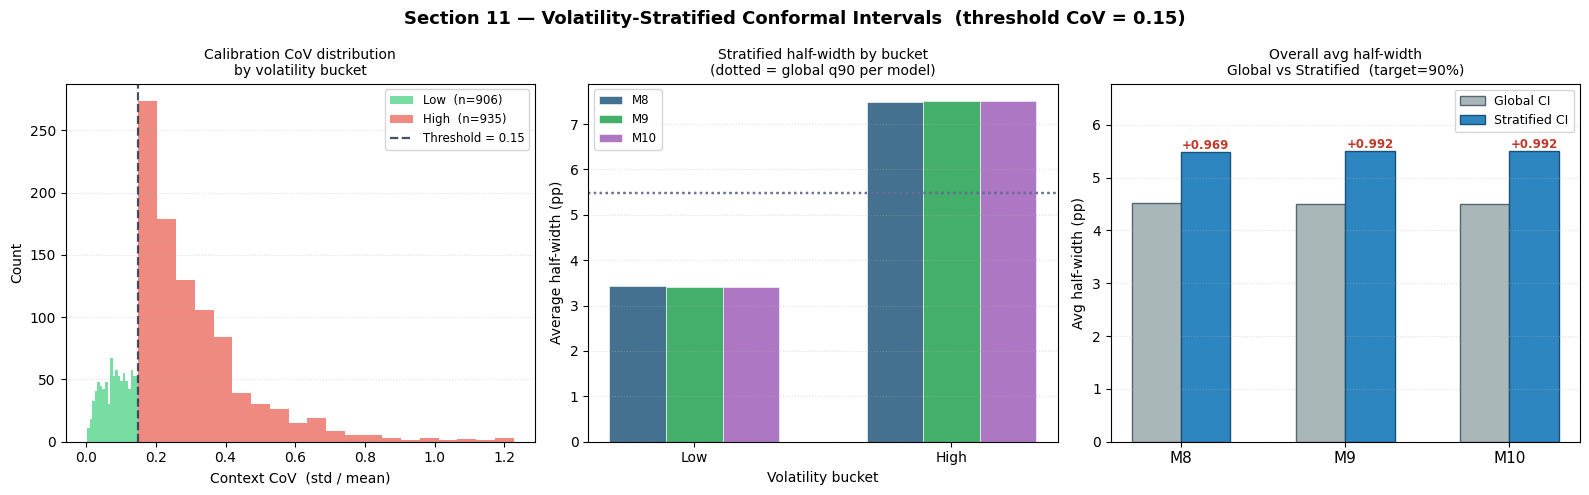

In [21]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Section 11 — Volatility-Stratified Conformal Intervals  '
             f'(threshold CoV = {VOL_THRESHOLD:.2f})', fontsize=13, fontweight='bold')

_bucket_colours = ['#2ecc71', '#e74c3c']   # Low = green, High = red
_model_colours  = {'M8': '#1a5276', 'M9': '#1a9e4a', 'M10': '#9b59b6'}
_models         = ['M8', 'M9', 'M10']

# ── Panel 1: CoV distribution by bucket (calibration set) ─────────────────────
ax = axes[0]
for b, (lbl, col) in enumerate(zip(VOL_LABELS, _bucket_colours)):
    vals = cal_cv[cal_vol_bins == b]
    ax.hist(vals, bins=20, alpha=0.65, color=col,
            label=f'{lbl}  (n={len(vals)})')
ax.axvline(VOL_THRESHOLD, color='#2c3e50', linestyle='--', linewidth=1.6, alpha=0.9,
           label=f'Threshold = {VOL_THRESHOLD:.2f}')
ax.set_xlabel('Context CoV  (std / mean)', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('Calibration CoV distribution\nby volatility bucket', fontsize=10)
ax.legend(fontsize=8.5)
ax.grid(axis='y', linestyle=':', alpha=0.4)

# ── Panel 2: Per-bucket stratified half-width (all models) ────────────────────
ax2 = axes[1]
_x  = np.arange(N_VOL_BINS)
_bw = 0.22
_hw_strat_arr = {'M8': hw_strat_m8, 'M9': hw_strat_m9, 'M10': hw_strat_m10}
_q90_global   = {'M8': q90_global,   'M9': q90_global_knn, 'M10': q90_global_dev}

for mi, mlabel in enumerate(_models):
    hw_by_bucket = [float(np.mean(_hw_strat_arr[mlabel][te_vol_bins == b]))
                    for b in range(N_VOL_BINS)]
    ax2.bar(_x + (mi - 1) * _bw, hw_by_bucket, _bw,
            label=mlabel, color=_model_colours[mlabel], alpha=0.82,
            edgecolor='white', linewidth=0.5)

# Dotted reference lines (global fallback per model)
for mlabel, col in _model_colours.items():
    ax2.axhline(_q90_global[mlabel], color=col, linestyle=':', linewidth=1.6, alpha=0.7)

ax2.set_xticks(_x)
ax2.set_xticklabels(VOL_LABELS, fontsize=10)
ax2.set_xlabel('Volatility bucket', fontsize=10)
ax2.set_ylabel('Average half-width (pp)', fontsize=10)
ax2.set_title('Stratified half-width by bucket\n(dotted = global q90 per model)', fontsize=10)
ax2.legend(fontsize=8.5)
ax2.grid(axis='y', linestyle=':', alpha=0.4)

# ── Panel 3: Global vs stratified avg half-width summary ─────────────────────
ax3 = axes[2]
_hw_g = [strat_results[m]['hw_g'] for m in _models]
_hw_s = [strat_results[m]['hw_s'] for m in _models]
_x3   = np.arange(len(_models))
_bw3  = 0.3

bars_g3 = ax3.bar(_x3 - _bw3/2, _hw_g, _bw3,
                  label='Global CI', color='#aab7b8', edgecolor='#566573', linewidth=1)
bars_s3 = ax3.bar(_x3 + _bw3/2, _hw_s, _bw3,
                  label='Stratified CI', color='#2e86c1', edgecolor='#1a5276', linewidth=1)

for bar, m in zip(bars_s3, _models):
    delta = strat_results[m]['delta_hw']
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.003,
             f'{delta:+.3f}', ha='center', va='bottom', fontsize=8.5,
             color='#1a5276' if delta < 0 else '#c0392b', fontweight='bold')

ax3.set_xticks(_x3)
ax3.set_xticklabels(_models, fontsize=11)
ax3.set_ylabel('Avg half-width (pp)', fontsize=10)
ax3.set_title(f'Overall avg half-width\nGlobal vs Stratified  (target={TARGET_COV:.0%})', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(axis='y', linestyle=':', alpha=0.4)
ax3.set_ylim(0, max(_hw_g) * 1.5)

plt.tight_layout()
plt.show()


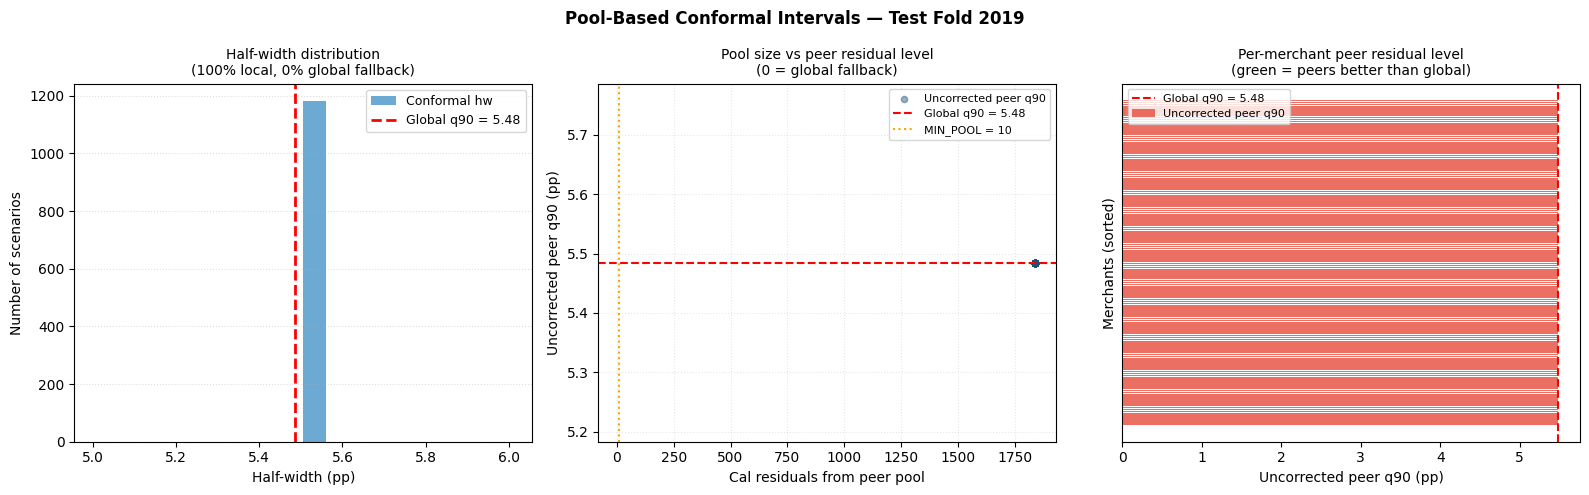

Scenarios with local peer pool (≥10 cal residuals) : 100.0%
Scenarios using global fallback                            : 0.0%

Merchants whose peer q90 < global q90 : 0.0%
Merchants whose peer q90 ≥ global q90 : 100.0%

Per-merchant coverage (test fold):
  Median joint coverage   : 1.000
  % merchants ≥ 90% joint : 86.0%
  % merchants ≥ 80% joint : 89.5%


In [22]:
# ── Pool-Based CI audit + visualisation ──────────────────────────────────────
# Because test and calibration merchants are disjoint groups, the peer pool
# for a test merchant rarely overlaps with cal merchants in merchant_cal_res.
# Most test scenarios therefore fall back to q90_global → hw_per_scenario is
# nearly constant. Panel 3 shows the uncorrected peer q90 as the bar (the
# quantity that actually varies) and reports the fallback rate in the summary.

test_merchant_ids = np.array([int(s['merchant_id']) for s in test_ci])
unique_test_mids  = sorted(set(test_merchant_ids))

# Per-scenario: uncorrected q90 of peer cal residuals (falls back to q90_global)
peer_q90_raw   = np.full(len(test_ci), q90_global)
peer_pool_size = np.zeros(len(test_ci), dtype=int)
for i, s in enumerate(test_ci):
    yr, mo      = s['context_range'][1]
    peer_mids_i = set(int(p) for p in
                      generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
    peer_res_i  = [r for peer in peer_mids_i for r in merchant_cal_res.get(peer, [])]
    peer_pool_size[i] = len(peer_res_i)
    if len(peer_res_i) >= MIN_POOL:
        peer_q90_raw[i] = float(np.quantile(peer_res_i, TARGET_COV))

local_rate = float(np.mean(peer_pool_size >= MIN_POOL)) * 100

# Per-merchant statistics
per_merchant_results = []
for mid in unique_test_mids:
    mask         = test_merchant_ids == mid
    y_m          = y_te[mask]
    lo_m         = lo_pool[mask]
    hi_m         = hi_pool[mask]
    hw_m_avg     = float(np.mean(hw_per_scenario[mask]))  # actual conformal hw (mostly = q90_global)
    q90_peer_avg = float(np.mean(peer_q90_raw[mask]))     # uncorrected peer residual level
    n_m_test     = int(np.sum(mask))

    in_m    = (y_m >= lo_m) & (y_m <= hi_m)
    joint_m = float(np.mean(in_m.all(axis=1))) if n_m_test > 0 else np.nan

    per_merchant_results.append({
        'merchant_id' : mid,
        'n_test'      : n_m_test,
        'avg_hw_pool' : hw_m_avg,
        'avg_q90_peer': q90_peer_avg,
        'hw_global'   : q90_global,
        'joint_pool'  : joint_m,
        'narrowed'    : q90_peer_avg < q90_global,
    })

df_merch = pd.DataFrame(per_merchant_results)

# ── 3-panel figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Pool-Based Conformal Intervals — Test Fold 2019', fontsize=12, fontweight='bold')

# Panel 1: Histogram of per-scenario half-widths
ax = axes[0]
ax.hist(hw_per_scenario, bins=18, color='#2e86c1', alpha=0.7, label='Conformal hw')
ax.axvline(q90_global, color='red', linestyle='--', linewidth=2,
           label=f'Global q90 = {q90_global:.2f}')
ax.set_xlabel('Half-width (pp)', fontsize=10)
ax.set_ylabel('Number of scenarios', fontsize=10)
ax.set_title(f'Half-width distribution\n({local_rate:.0f}% local, {100-local_rate:.0f}% global fallback)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.4)

# Panel 2: Pool size vs uncorrected peer q90
ax2 = axes[1]
ax2.scatter(peer_pool_size, peer_q90_raw, alpha=0.45, s=20, color='#1a5276',
            label='Uncorrected peer q90')
ax2.axhline(q90_global, color='red', linestyle='--', linewidth=1.5,
            label=f'Global q90 = {q90_global:.2f}')
ax2.axvline(MIN_POOL, color='orange', linestyle=':', linewidth=1.5,
            label=f'MIN_POOL = {MIN_POOL}')
ax2.set_xlabel('Cal residuals from peer pool', fontsize=10)
ax2.set_ylabel('Uncorrected peer q90 (pp)', fontsize=10)
ax2.set_title('Pool size vs peer residual level\n(0 = global fallback)', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(linestyle=':', alpha=0.3)

# Panel 3: Per-merchant peer q90 (what actually varies)
ax3 = axes[2]
df_sorted = df_merch.sort_values('avg_q90_peer').reset_index(drop=True)
bar_cols   = ['#148f77' if v else '#e74c3c' for v in df_sorted['narrowed']]
ax3.barh(range(len(df_sorted)), df_sorted['avg_q90_peer'], color=bar_cols, alpha=0.80,
         label='Uncorrected peer q90')
ax3.axvline(q90_global, color='red', linestyle='--', linewidth=1.5,
            label=f'Global q90 = {q90_global:.2f}')
ax3.set_xlabel('Uncorrected peer q90 (pp)', fontsize=10)
ax3.set_ylabel('Merchants (sorted)', fontsize=10)
ax3.set_title('Per-merchant peer residual level\n(green = peers better than global)', fontsize=10)
ax3.legend(fontsize=8)
ax3.set_yticks([])

plt.tight_layout()
plt.show()

# Summary
narrowed_pct = df_merch['narrowed'].mean() * 100
print(f"Scenarios with local peer pool (≥{MIN_POOL} cal residuals) : {local_rate:.1f}%")
print(f"Scenarios using global fallback                            : {100-local_rate:.1f}%")
print()
print(f"Merchants whose peer q90 < global q90 : {narrowed_pct:.1f}%")
print(f"Merchants whose peer q90 ≥ global q90 : {100-narrowed_pct:.1f}%")
print()
print(f"Per-merchant coverage (test fold):")
print(f"  Median joint coverage   : {df_merch['joint_pool'].median():.3f}")
print(f"  % merchants ≥ 90% joint : {(df_merch['joint_pool'] >= 0.90).mean()*100:.1f}%")
print(f"  % merchants ≥ 80% joint : {(df_merch['joint_pool'] >= 0.80).mean()*100:.1f}%")


## 9. End-to-End Evaluation

`models_ci` (M8), `models_knn` (M9), and `models_dev` (M10) evaluated across all three splits — no fold switching, one consistent model per variant.

| Split | Merchants | Horizon year | Role |
|---|---|---|---|
| Train (in-sample) | train 60% | < 2018 | Lower bound — all models trained on this data |
| Validate / Cal | validate 20% | == 2018 | First true OOS signal — unseen merchants, structurally elevated cost year |
| Test (held-out) | test 20% | == 2019 | Honest final number — unseen merchants, final data year |

**Note on Train MAE vs Validate/Test MAE:** If train MAE exceeds validate or test MAE, this is expected and does not indicate overfitting. `train_ci` aggregates all years from the start of the dataset through to 2017, including early high-volatility periods. `test_ci` covers only 2019, which may have a more concentrated cost distribution — naturally producing a lower aggregate error. The multi-year composition of the training pool is what this model is designed to generalise over.

Green / purple % labels show M9/M10 improvement over the mean-context baseline. **M10's key test** is whether training on deviation from pool mean reduces MAE on the anomalous-year split (Validate = 2018, elevated costs) relative to the final-year split (Test = 2019).


                                  End-to-End Evaluation                                   

Train (in-sample)  (train merchants, horizon < 2018)  n=41,925
  Baseline=1.3426  M8=1.2853 (-4.27% ✓)  M9=1.2853 (-4.27% ✓)  M10=1.2853 (-4.27% ✓)
  Best model: M8  |  M10 vs M9: +0.00%  M10 vs M8: +0.00%
  M8  per step: t+1=1.2799  t+2=1.2832  t+3=1.2928
  M9  per step: t+1=1.2802  t+2=1.2831  t+3=1.2926
  M10 per step: t+1=1.2802  t+2=1.2831  t+3=1.2926

Validate / Cal  (validate merchants, horizon == 2018)  n=1,841
  Baseline=2.2319  M8=2.0731 (-7.11% ✓)  M9=2.0679 (-7.34% ✓)  M10=2.0679 (-7.35% ✓)
  Best model: M10  |  M10 vs M9: -0.00%  M10 vs M8: -0.25%
  M8  per step: t+1=2.0654  t+2=1.9469  t+3=2.2070
  M9  per step: t+1=2.0604  t+2=1.9573  t+3=2.1862
  M10 per step: t+1=2.0604  t+2=1.9573  t+3=2.1862

Test (held-out)  (test merchants, horizon == 2019)  n=1,183
  Baseline=1.3345  M8=1.3039 (-2.29% ✓)  M9=1.3057 (-2.15% ✓)  M10=1.3057 (-2.15% ✓)
  Best model: M8  |  M10 vs M9: +0.00%  M1

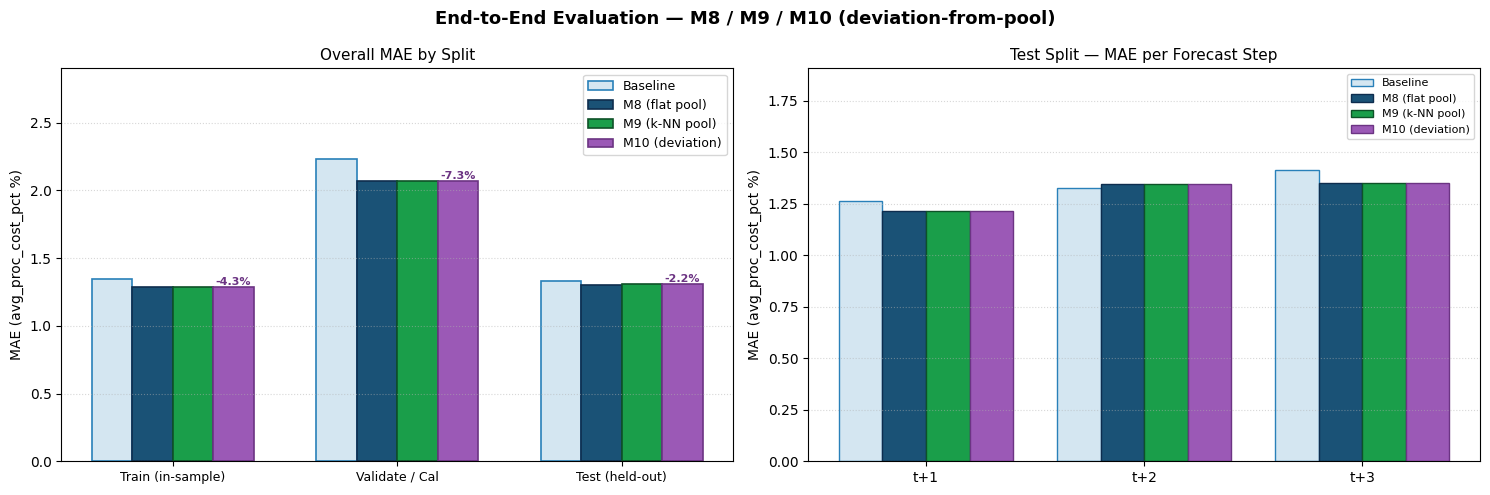

In [23]:
# In-sample predictions for all models
tr_preds     = np.zeros_like(y_tr, dtype=float)
tr_preds_knn = np.zeros_like(y_tr, dtype=float)
tr_preds_dev = np.zeros_like(y_tr, dtype=float)
for h in range(3):
    tr_preds[:, h]     = models_ci[h].predict(X_tr)
    tr_preds_knn[:, h] = models_knn[h].predict(X_tr_knn)
    # M10: predict deviation, add back pool mean
    tr_preds_dev[:, h] = models_dev[h].predict(X_tr_dev) + pool_tr_dev

# Baseline predictions for each split (flat context mean)
base_tr_preds  = np.array([[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * 3 for s in train_ci])
base_cal_preds = np.array([[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * 3 for s in cal_ci])
base_te_preds  = np.array([[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * 3 for s in test_ci])

splits = [
    ('Train (in-sample)', y_tr,  tr_preds,  tr_preds_knn,  tr_preds_dev,  base_tr_preds,
     f'train merchants, horizon < {_cal_year}'),
    ('Validate / Cal',    y_cal, cal_preds, cal_preds_knn, cal_preds_dev, base_cal_preds,
     f'validate merchants, horizon == {_cal_year}'),
    ('Test (held-out)',   y_te,  te_preds,  te_preds_knn,  te_preds_dev,  base_te_preds,
     f'test merchants, horizon == {_test_year}'),
]

print("=" * 90)
print(f"{'End-to-End Evaluation':^90}")
print("=" * 90)

rows = []
for label, y, preds_m8, preds_m9, preds_m10, base, note in splits:
    base_mae = float(np.mean(np.abs(y - base)))
    m8_mae   = float(np.mean(np.abs(y - preds_m8)))
    m9_mae   = float(np.mean(np.abs(y - preds_m9)))
    m10_mae  = float(np.mean(np.abs(y - preds_m10)))
    m8_impr  = (m8_mae  - base_mae) / base_mae * 100
    m9_impr  = (m9_mae  - base_mae) / base_mae * 100
    m10_impr = (m10_mae - base_mae) / base_mae * 100
    steps_m8  = [float(np.mean(np.abs(y[:, h] - preds_m8[:, h])))  for h in range(3)]
    steps_m9  = [float(np.mean(np.abs(y[:, h] - preds_m9[:, h])))  for h in range(3)]
    steps_m10 = [float(np.mean(np.abs(y[:, h] - preds_m10[:, h]))) for h in range(3)]
    rows.append((label, note, base_mae, m8_mae, m9_mae, m10_mae,
                 m8_impr, m9_impr, m10_impr, steps_m8, steps_m9, steps_m10))

    print(f"\n{label}  ({note})  n={len(y):,}")
    print(f"  Baseline={base_mae:.4f}  "
          f"M8={m8_mae:.4f} ({m8_impr:+.2f}% {'✓' if m8_mae < base_mae else '✗'})  "
          f"M9={m9_mae:.4f} ({m9_impr:+.2f}% {'✓' if m9_mae < base_mae else '✗'})  "
          f"M10={m10_mae:.4f} ({m10_impr:+.2f}% {'✓' if m10_mae < base_mae else '✗'})")
    best = min(m8_mae, m9_mae, m10_mae)
    winner = 'M8' if best == m8_mae else ('M9' if best == m9_mae else 'M10')
    print(f"  Best model: {winner}  |  "
          f"M10 vs M9: {(m10_mae - m9_mae)/m9_mae*100:+.2f}%  "
          f"M10 vs M8: {(m10_mae - m8_mae)/m8_mae*100:+.2f}%")
    print(f"  M8  per step: t+1={steps_m8[0]:.4f}  t+2={steps_m8[1]:.4f}  t+3={steps_m8[2]:.4f}")
    print(f"  M9  per step: t+1={steps_m9[0]:.4f}  t+2={steps_m9[1]:.4f}  t+3={steps_m9[2]:.4f}")
    print(f"  M10 per step: t+1={steps_m10[0]:.4f}  t+2={steps_m10[1]:.4f}  t+3={steps_m10[2]:.4f}")

print(f"\n{'='*90}")
print(f"  CV   M8={avg_m8:.6f}  M9={avg_m9:.6f}  M10={avg_m10:.6f}")
print(f"  Val  M8={rows[1][3]:.6f}  M9={rows[1][4]:.6f}  M10={rows[1][5]:.6f}")
print(f"  Test M8={rows[2][3]:.6f}  M9={rows[2][4]:.6f}  M10={rows[2][5]:.6f}")
print("=" * 90)

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('End-to-End Evaluation — M8 / M9 / M10 (deviation-from-pool)',
             fontsize=13, fontweight='bold')

x      = np.arange(len(rows))
bar_w  = 0.18

bars_b   = ax1.bar(x - 1.5*bar_w, [r[2] for r in rows], bar_w, label='Baseline',
                   color='#d4e6f1', edgecolor='#2980b9', linewidth=1.2)
bars_m8  = ax1.bar(x - 0.5*bar_w, [r[3] for r in rows], bar_w, label='M8 (flat pool)',
                   color='#1a5276', edgecolor='#0e2d4e', linewidth=1.2)
bars_m9  = ax1.bar(x + 0.5*bar_w, [r[4] for r in rows], bar_w, label='M9 (k-NN pool)',
                   color='#1a9e4a', edgecolor='#0e5228', linewidth=1.2)
bars_m10 = ax1.bar(x + 1.5*bar_w, [r[5] for r in rows], bar_w, label='M10 (deviation)',
                   color='#9b59b6', edgecolor='#6c3483', linewidth=1.2)

for bar, r in zip(bars_m10, rows):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{r[8]:+.1f}%', ha='center', va='bottom', fontsize=8,
             color='#6c3483', fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels([r[0] for r in rows], fontsize=9)
ax1.set_ylabel('MAE (avg_proc_cost_pct %)', fontsize=10)
ax1.set_title('Overall MAE by Split', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_ylim(0, max(r[2] for r in rows) * 1.3)
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# Per-step comparison on test split
steps_b    = [float(np.mean(np.abs(y_te[:, h] - base_te_preds[:, h]))) for h in range(3)]
steps_m8t  = rows[2][9]
steps_m9t  = rows[2][10]
steps_m10t = rows[2][11]
x2   = np.arange(3)
bw   = 0.2
ax2.bar(x2 - 1.5*bw, steps_b,    bw, label='Baseline',       color='#d4e6f1', edgecolor='#2980b9', linewidth=1.0)
ax2.bar(x2 - 0.5*bw, steps_m8t,  bw, label='M8 (flat pool)', color='#1a5276', edgecolor='#0e2d4e', linewidth=1.0)
ax2.bar(x2 + 0.5*bw, steps_m9t,  bw, label='M9 (k-NN pool)', color='#1a9e4a', edgecolor='#0e5228', linewidth=1.0)
ax2.bar(x2 + 1.5*bw, steps_m10t, bw, label='M10 (deviation)', color='#9b59b6', edgecolor='#6c3483', linewidth=1.0)
ax2.set_xticks(x2)
ax2.set_xticklabels(['t+1', 't+2', 't+3'], fontsize=10)
ax2.set_ylabel('MAE (avg_proc_cost_pct %)', fontsize=10)
ax2.set_title('Test Split — MAE per Forecast Step', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(axis='y', linestyle=':', alpha=0.5)
ax2.set_ylim(0, max(steps_b) * 1.35)

plt.tight_layout()
plt.show()


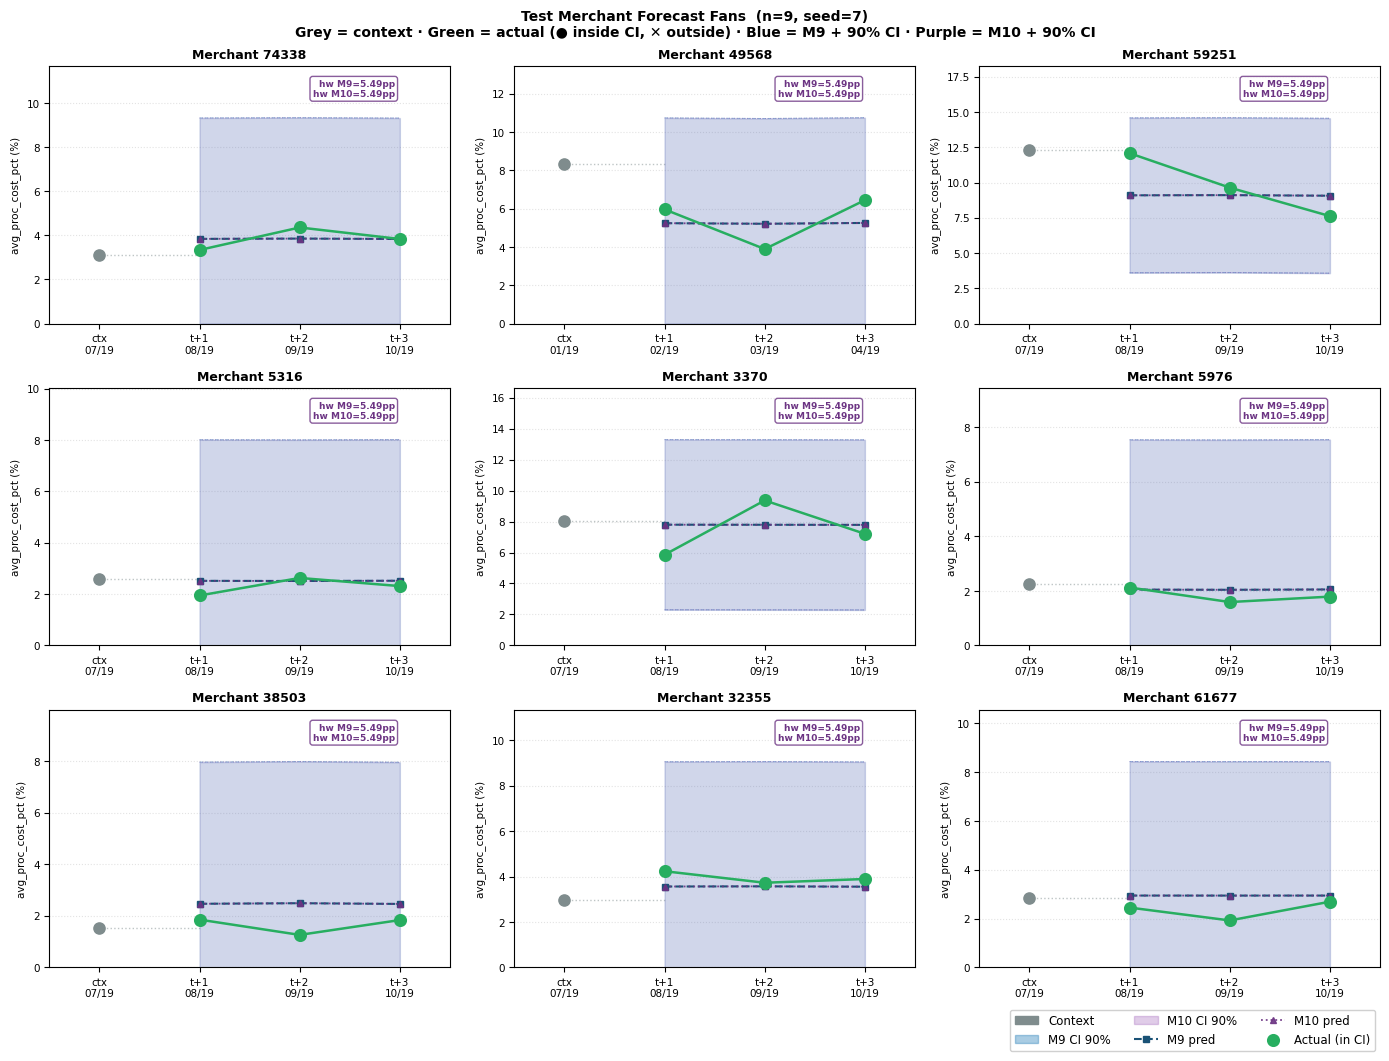

In [24]:
# ── Sample merchant forecast fans ─────────────────────────────────────────────
# For each sampled test merchant: pick their most recent test scenario, then
# plot context anchor → 3-step forecast with actuals, M9/M10 predictions, and
# M9 conformal interval band.

_SAMPLE_N  = 9
_VIS_SEED  = 7

# Build lookup: merchant → (context_end_key, scenario_idx)
_mid_to_last: dict = {}
for _idx, _s in enumerate(test_ci):
    _mid  = int(_s['merchant_id'])
    _ckey = _s['context_range'][1]   # (year, month)
    if _mid not in _mid_to_last or _ckey > _mid_to_last[_mid][0]:
        _mid_to_last[_mid] = (_ckey, _idx)

_all_vis_mids = list(_mid_to_last.keys())
_rng_vis      = np.random.default_rng(_VIS_SEED)
_perm_vis     = _rng_vis.permutation(len(_all_vis_mids))
_sample_mids  = [_all_vis_mids[i] for i in _perm_vis[:_SAMPLE_N]]

# ── Plot ──────────────────────────────────────────────────────────────────────
ncols = 3
nrows = math.ceil(_SAMPLE_N / ncols)
x_step = np.array([1, 2, 3])

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.6), squeeze=False)
fig.suptitle(
    f'Test Merchant Forecast Fans  (n={_SAMPLE_N}, seed={_VIS_SEED})\n'
    'Grey = context · Green = actual (● inside CI, ✕ outside) · '
    'Blue = M9 + 90% CI · Purple = M10 + 90% CI',
    fontsize=10, fontweight='bold'
)

for _plot_i, _mid in enumerate(_sample_mids):
    _row, _col = divmod(_plot_i, ncols)
    ax = axes[_row][_col]

    _, _idx = _mid_to_last[_mid]
    _s      = test_ci[_idx]

    ctx_val  = float(_s['context_data']['avg_proc_cost_pct'].values[-1])
    act      = y_te[_idx]
    pred_m9  = te_preds_knn[_idx]
    lo_m9    = lo_pool_knn[_idx]
    hi_m9    = hi_pool_knn[_idx]
    pred_m10 = te_preds_dev[_idx]
    lo_m10   = lo_pool_dev[_idx]
    hi_m10   = hi_pool_dev[_idx]

    _cy, _cm = _s['context_range'][1]
    _h_dates = [
        (int(_s['horizon_data'].iloc[h]['year']),
         int(_s['horizon_data'].iloc[h]['month']))
        for h in range(3)
    ]
    x_labels = (
        [f"ctx\n{_cm:02d}/{_cy % 100:02d}"] +
        [f"t+{h+1}\n{_hm:02d}/{_hy % 100:02d}" for h, (_hy, _hm) in enumerate(_h_dates)]
    )

    # Context anchor
    ax.scatter([0], [ctx_val], color='#7f8c8d', s=65, zorder=6)
    ax.plot([0, 1], [ctx_val, ctx_val], color='#7f8c8d', linestyle=':', linewidth=1, alpha=0.5)

    # M9: CI band + prediction
    ax.fill_between(x_step, lo_m9, hi_m9, alpha=0.18, color='#2980b9', zorder=2)
    ax.plot(x_step, lo_m9, '--', color='#2980b9', linewidth=0.7, alpha=0.5)
    ax.plot(x_step, hi_m9, '--', color='#2980b9', linewidth=0.7, alpha=0.5)
    ax.plot(x_step, pred_m9, 's--', color='#1a5276', linewidth=1.5, markersize=5, zorder=5,
            label='M9 pred')

    # M10: CI band + prediction
    ax.fill_between(x_step, lo_m10, hi_m10, alpha=0.12, color='#9b59b6', zorder=2)
    ax.plot(x_step, lo_m10, ':', color='#9b59b6', linewidth=0.7, alpha=0.5)
    ax.plot(x_step, hi_m10, ':', color='#9b59b6', linewidth=0.7, alpha=0.5)
    ax.plot(x_step, pred_m10, '^:', color='#6c3483', linewidth=1.3, markersize=4, zorder=5,
            alpha=0.9, label='M10 pred')

    # Actuals — coloured by whether they're inside the M9 CI
    ax.plot(x_step, act, '-', color='#27ae60', linewidth=1.8, zorder=7)
    for h in range(3):
        _inside = lo_m9[h] <= act[h] <= hi_m9[h]
        ax.scatter([x_step[h]], [act[h]],
                   marker='o' if _inside else 'x',
                   color='#27ae60' if _inside else '#e74c3c',
                   s=55 if _inside else 80, zorder=8, linewidths=2,
                   label=('Actual (in CI)' if _inside else 'Actual (out CI)') if h == 0 else None)

    ax.set_xticks([0] + list(x_step))
    ax.set_xticklabels(x_labels, fontsize=7.5)
    ax.set_title(f'Merchant {_mid}', fontsize=9, fontweight='bold')
    ax.set_ylabel('avg_proc_cost_pct (%)', fontsize=7.5)
    ax.yaxis.set_tick_params(labelsize=7.5)
    ax.grid(axis='y', linestyle=':', alpha=0.35)
    ax.set_ylim(0,max(act.max(), hi_m10.max()) * 1.25)
    ax.set_xlim(-0.5, 3.5)
    
    # show half-width in graph for quick reference
    ax.text(2.95, ax.get_ylim()[1]*0.95, f"hw M9={float(np.mean(hi_m9 - pred_m9)):.2f}pp\n"
                                        f"hw M10={float(np.mean(hi_m10 - pred_m10)):.2f}pp",
            ha='right', va='top', fontsize=6.5, color='#6c3483', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='#6c3483'))

# Shared legend from first subplot
_handles, _labels = axes[0][0].get_legend_handles_labels()
# Deduplicate
_seen, _h_uniq, _l_uniq = set(), [], []
for _h, _l in zip(_handles, _labels):
    if _l not in _seen:
        _seen.add(_l); _h_uniq.append(_h); _l_uniq.append(_l)

# Add context manually
_ctx_patch = mpatches.Patch(color='#7f8c8d', label='Context')
_m9ci_patch = mpatches.Patch(color='#2980b9', alpha=0.4, label='M9 CI 90%')
_m10ci_patch = mpatches.Patch(color='#9b59b6', alpha=0.3, label='M10 CI 90%')
_h_uniq = [_ctx_patch, _m9ci_patch, _m10ci_patch] + _h_uniq
_l_uniq = ['Context', 'M9 CI 90%', 'M10 CI 90%'] + _l_uniq

# Hide unused subplots
for _plot_i in range(_SAMPLE_N, nrows * ncols):
    _row, _col = divmod(_plot_i, ncols)
    axes[_row][_col].set_visible(False)

fig.legend(_h_uniq, _l_uniq, loc='lower right', fontsize=8.5, ncol=3,
           bbox_to_anchor=(0.99, 0.01), framealpha=0.92)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


Feature variance in training data (context_len=1 effect)
────────────────────────────────────────────────────────────
  context_mean        variance = 19.659056
  context_std         variance = 5.651412
  momentum            variance = 6.811402
  pool_mean           variance = 0.000943


══════════════════════════════════════════════════════════════
  M8 (flat pool)
══════════════════════════════════════════════════════════════
  Feature                    t+1         t+2         t+3  notes
  ──────────────────────────────────────────────────────────
  context_mean            4.3124      4.3107      4.2709
  context_std            -1.1256     -1.1354     -1.0991
  momentum                0.0276     -0.0145      0.0406
  pool_mean              -0.0097     -0.0079     -0.0045
  intercept               4.0413      4.0379      4.0369
  (Scaled coefficients — units are in standardised feature space)

  Effective terms (original units, ignoring zero-variance features):
    t+1: +0.9726·conte

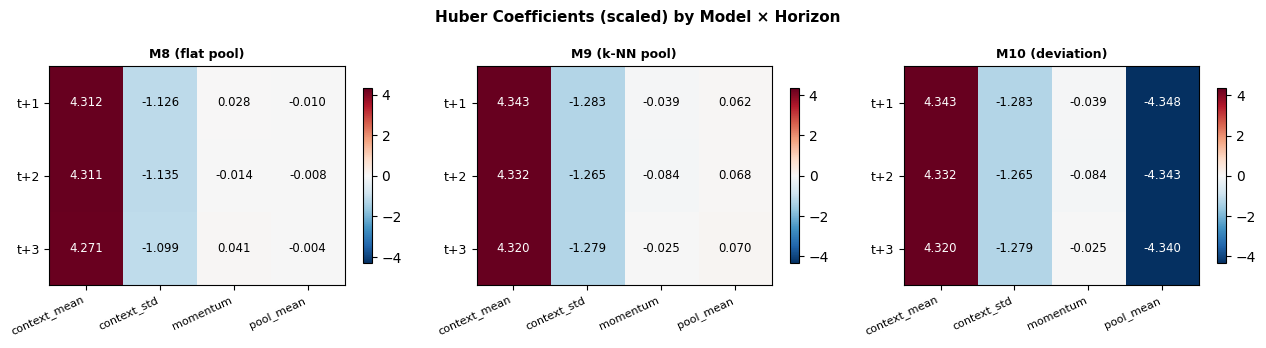


Diagnosis
────────────────────────────────────────────────────────────
• context_std and momentum are permanently 0 with context_len=1.
  The model operates on just 2 real features: context_mean + pool_mean.

• Flat predictions: each horizon model learns similar α/β weights,
  so t+1, t+2, t+3 predictions are nearly identical (no trend encoded).

• Conservative CIs: calibrated on 2018 (validate set) where costs were
  structurally elevated → residuals were large → q90 is wide for all years.

• Fix for flatness:  increase context_len ≥ 3 to activate context_std
  and momentum as real signals, enabling the model to learn cost trends.


In [25]:
# ── Huber coefficient inspection ─────────────────────────────────────────────
# With context_len=1:
#   context_std  = std([single value]) = 0  for EVERY scenario
#   momentum     = val - mean([val])   = 0  for EVERY scenario
# These two features are zero-variance — StandardScaler leaves them as 0
# after transform. They contribute nothing to predictions.
# Effectively the model is:  ŷ = α·context_mean + β·pool_mean + intercept

print("Feature variance in training data (context_len=1 effect)")
print("─" * 60)
feat_var_m8 = X_tr_raw.var(axis=0)
for fname, var in zip(FEAT_NAMES_M8, feat_var_m8):
    flag = "  ← always 0!" if var < 1e-10 else ""
    print(f"  {fname:<18}  variance = {var:.6f}{flag}")

print()

# ── Coefficient tables ────────────────────────────────────────────────────────
model_groups = [
    ('M8 (flat pool)',  models_ci,  scaler_ci),
    ('M9 (k-NN pool)',  models_knn, scaler_knn),
    ('M10 (deviation)', models_dev, scaler_dev),
]

for model_label, model_list, scaler in model_groups:
    print(f"\n{'═'*62}")
    print(f"  {model_label}")
    print(f"{'═'*62}")

    # Column header
    hdr = f"  {'Feature':<18}" + "".join(f"  {'t+'+str(h+1):>10}" for h in range(3)) + "  notes"
    print(hdr)
    print("  " + "─" * 58)

    # Scaled coefficients (what the model actually operates on)
    coef_matrix = np.array([m.coef_ for m in model_list])     # (3, 4)
    intercepts  = np.array([m.intercept_ for m in model_list]) # (3,)

    for f_idx, fname in enumerate(FEAT_NAMES_M8):
        row = f"  {fname:<18}" + "".join(f"  {coef_matrix[h, f_idx]:>10.4f}" for h in range(3))
        if feat_var_m8[f_idx] < 1e-10:
            row += "  (zero-variance feature)"
        print(row)

    row = f"  {'intercept':<18}" + "".join(f"  {intercepts[h]:>10.4f}" for h in range(3))
    print(row)
    print("  (Scaled coefficients — units are in standardised feature space)")

    # Back-transform to original units for the two effective features
    # coef_raw[f] = coef_scaled[f] / scale[f]
    # context_mean and pool_mean are indices 0 and 3
    scale = scaler.scale_     # (4,)
    mean_ = scaler.mean_      # (4,)
    coef_raw = coef_matrix / scale[None, :]   # (3, 4)

    print()
    print(f"  Effective terms (original units, ignoring zero-variance features):")
    for h in range(3):
        # ŷ = coef_raw[0]*context_mean + coef_raw[3]*pool_mean + adj_intercept
        a  = coef_raw[h, 0]   # context_mean coefficient
        b  = coef_raw[h, 3]   # pool_mean coefficient
        c  = (model_list[h].intercept_
              - (coef_matrix[h] * mean_ / scale).sum())  # adjusted intercept
        print(f"    t+{h+1}: {a:+.4f}·context_mean  {b:+.4f}·pool_mean  {c:+.4f}  "
              f"(sum of weights = {a+b:.4f})")

# ── Coefficient heatmap ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
fig.suptitle("Huber Coefficients (scaled) by Model × Horizon",
             fontsize=11, fontweight='bold')

cmap = plt.cm.RdBu_r
for ax, (mlabel, mlist, _) in zip(axes, model_groups):
    coef_mat = np.array([m.coef_ for m in mlist])  # (3, 4): rows=horizon, cols=features
    vmax = np.abs(coef_mat).max()
    im = ax.imshow(coef_mat, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(4))
    ax.set_xticklabels(FEAT_NAMES_M8, fontsize=8, rotation=25, ha='right')
    ax.set_yticks(range(3))
    ax.set_yticklabels(['t+1', 't+2', 't+3'], fontsize=9)
    ax.set_title(mlabel, fontsize=9, fontweight='bold')
    for hi in range(3):
        for fi in range(4):
            ax.text(fi, hi, f'{coef_mat[hi, fi]:.3f}',
                    ha='center', va='center', fontsize=8.5,
                    color='white' if abs(coef_mat[hi, fi]) > vmax * 0.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

# ── Diagnosis summary ─────────────────────────────────────────────────────────
print()
print("Diagnosis")
print("─" * 60)
print("• context_std and momentum are permanently 0 with context_len=1.")
print("  The model operates on just 2 real features: context_mean + pool_mean.")
print()
print("• Flat predictions: each horizon model learns similar α/β weights,")
print("  so t+1, t+2, t+3 predictions are nearly identical (no trend encoded).")
print()
print("• Conservative CIs: calibrated on 2018 (validate set) where costs were")
print("  structurally elevated → residuals were large → q90 is wide for all years.")
print()
print("• Fix for flatness:  increase context_len ≥ 3 to activate context_std")
print("  and momentum as real signals, enabling the model to learn cost trends.")


## 10. Coverage Level Sweep

Sweep the target coverage level from 50% to 95% and record achieved joint coverage and average interval width on `test_ci`. A well-calibrated model should track the nominal line closely.


  M8 (flat)  50%  →  joint=0.484  hw=±1.0889
  M8 (flat)  60%  →  joint=0.589  hw=±1.4771
  M8 (flat)  70%  →  joint=0.711  hw=±2.0260
  M8 (flat)  80%  →  joint=0.836  hw=±3.1014
  M8 (flat)  90%  →  joint=0.934  hw=±5.5057
  M8 (flat)  95%  →  joint=0.969  hw=±9.1331
  M9 (k-NN)  50%  →  joint=0.481  hw=±1.0785
  M9 (k-NN)  60%  →  joint=0.587  hw=±1.4786
  M9 (k-NN)  70%  →  joint=0.705  hw=±2.0322
  M9 (k-NN)  80%  →  joint=0.842  hw=±3.1074
  M9 (k-NN)  90%  →  joint=0.934  hw=±5.4925
  M9 (k-NN)  95%  →  joint=0.969  hw=±9.1543
  M10 (dev)  50%  →  joint=0.481  hw=±1.0785
  M10 (dev)  60%  →  joint=0.587  hw=±1.4786
  M10 (dev)  70%  →  joint=0.705  hw=±2.0322
  M10 (dev)  80%  →  joint=0.842  hw=±3.1074
  M10 (dev)  90%  →  joint=0.934  hw=±5.4925
  M10 (dev)  95%  →  joint=0.969  hw=±9.1543


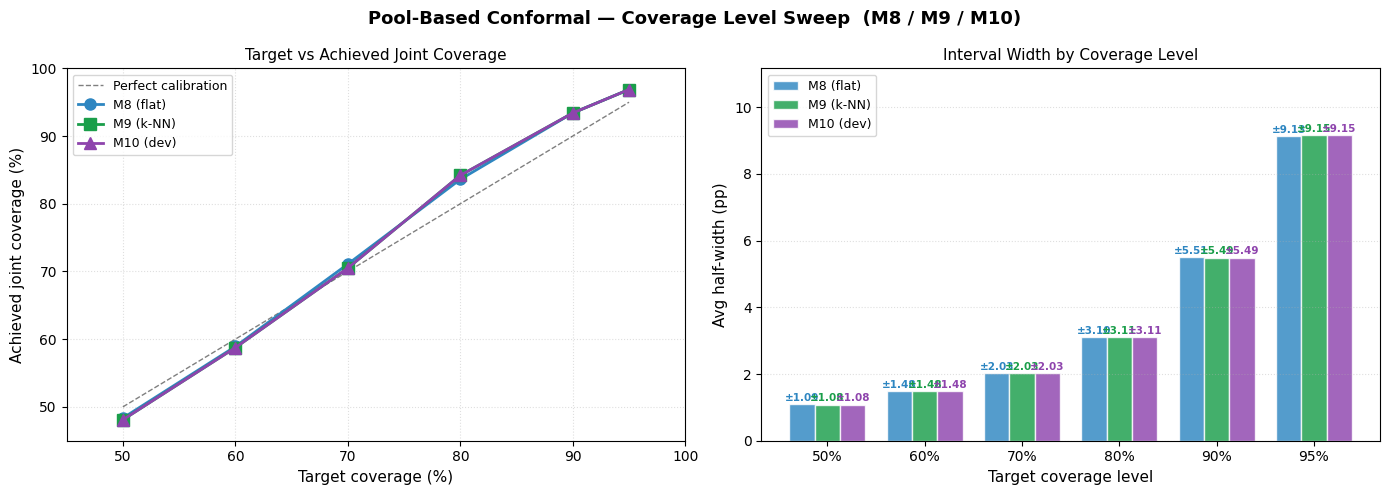

In [26]:

LEVELS = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

_model_cfgs = [
    ('M8 (flat)',  merchant_cal_res,     cal_max_res_raw,  te_preds),
    ('M9 (k-NN)', merchant_cal_res_knn,  cal_max_res_knn,  te_preds_knn),
    ('M10 (dev)',  merchant_cal_res_dev,  cal_max_res_dev,  te_preds_dev),
]

all_sweep = {}   # model_label -> list of dicts

for m_label, cal_res_map, global_res, preds_m in _model_cfgs:
    results = []
    for target in LEVELS:
        hw_sw = np.zeros(len(test_ci))
        for i, s in enumerate(test_ci):
            yr, mo    = s['context_range'][1]
            peer_mids = set(int(p) for p in
                            generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
            peer_res  = [r for peer in peer_mids for r in cal_res_map.get(peer, [])]

            n     = len(peer_res)
            level = math.ceil((n + 1) * target) / n if n >= MIN_POOL else None
            if level is not None and level <= 1.0:
                hw_sw[i] = float(np.quantile(peer_res, level))
            else:
                gl       = math.ceil((len(global_res) + 1) * target) / len(global_res)
                hw_sw[i] = float(np.quantile(global_res, min(gl, 1.0)))

        in_sw    = (y_te >= preds_m - hw_sw[:, None]) & (y_te <= preds_m + hw_sw[:, None])
        joint_sw = float(np.mean(in_sw.all(axis=1)))
        avg_hw   = float(np.mean(hw_sw))
        results.append({'target': target, 'joint_cov': joint_sw, 'avg_hw': avg_hw})
        print(f"  {m_label}  {target*100:.0f}%  →  joint={joint_sw:.3f}  hw=±{avg_hw:.4f}")

    all_sweep[m_label] = results

# ── Chart ─────────────────────────────────────────────────────────────────────
_colours = {'M8 (flat)': '#2e86c1', 'M9 (k-NN)': '#1a9e4a', 'M10 (dev)': '#8e44ad'}
_markers = {'M8 (flat)': 'o', 'M9 (k-NN)': 's', 'M10 (dev)': '^'}
_bar_w   = 0.26
_x       = np.arange(len(LEVELS))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pool-Based Conformal — Coverage Level Sweep  (M8 / M9 / M10)',
             fontsize=13, fontweight='bold')

# Panel 1: target vs achieved joint coverage
ax1.plot([50, 95], [50, 95], 'k--', linewidth=1, alpha=0.5, label='Perfect calibration')
for m_label, results in all_sweep.items():
    targets_l = [r['target']    for r in results]
    covs_l    = [r['joint_cov'] for r in results]
    ax1.plot([t * 100 for t in targets_l], [c * 100 for c in covs_l],
             marker=_markers[m_label], linewidth=2, color=_colours[m_label],
             markersize=8, label=m_label)
ax1.set_xlabel('Target coverage (%)', fontsize=11)
ax1.set_ylabel('Achieved joint coverage (%)', fontsize=11)
ax1.set_title('Target vs Achieved Joint Coverage', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(linestyle=':', alpha=0.4)
ax1.set_xlim(45, 100); ax1.set_ylim(45, 100)

# Panel 2: avg half-width by coverage level (grouped bars)
for k, (m_label, results) in enumerate(all_sweep.items()):
    hws_l = [r['avg_hw'] for r in results]
    offset = (k - 1) * _bar_w
    bars = ax2.bar(_x + offset, hws_l, width=_bar_w,
                   color=_colours[m_label], alpha=0.82, edgecolor='white', label=m_label)
    for bar, hw in zip(bars, hws_l):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
                 f'±{hw:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold',
                 color=_colours[m_label])

ax2.set_xticks(_x)
ax2.set_xticklabels([f'{int(t*100)}%' for t in LEVELS])
ax2.set_xlabel('Target coverage level', fontsize=11)
ax2.set_ylabel('Avg half-width (pp)', fontsize=11)
ax2.set_title('Interval Width by Coverage Level', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle=':', alpha=0.4)
max_hw = max(r['avg_hw'] for res in all_sweep.values() for r in res)
ax2.set_ylim(0, max_hw * 1.22)

plt.tight_layout()
plt.show()


In [27]:
# get actual variance of the merchants at each coverage level to compare against the avg half-widths

print("\nActual variance of test merchants at each coverage level:")
print("─" * 60)
for m_label, results in all_sweep.items():
    print(f"\n{m_label}")
    for r in results:
        target = r['target']
        hw_sw = np.zeros(len(test_ci))
        for i, s in enumerate(test_ci):
            yr, mo    = s['context_range'][1]
            peer_mids = set(int(p) for p in
                            generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
            peer_res  = [r for peer in peer_mids for r in cal_res_map.get(peer, [])]

            n     = len(peer_res)
            level = math.ceil((n + 1) * target) / n if n >= MIN_POOL else None
            if level is not None and level <= 1.0:
                hw_sw[i] = float(np.quantile(peer_res, level))
            else:
                gl       = math.ceil((len(global_res) + 1) * target) / len(global_res)
                hw_sw[i] = float(np.quantile(global_res, min(gl, 1.0)))

        # Calculate actual variance of test merchants within the interval defined by hw_sw
        lower_bounds = preds_m - hw_sw[:, None]
        upper_bounds = preds_m + hw_sw[:, None]
        in_interval = (y_te >= lower_bounds) & (y_te <= upper_bounds)
        variance_within_interval = np.var(y_te[in_interval.all(axis=1)], axis=0)
        print(f"  Target {int(target*100)}%: Variance within interval = {variance_within_interval}")
        
        # find degree of actual conservatism by comparing variance_within_interval to avg_hw
        conservatism_factor = variance_within_interval / (r['avg_hw'] ** 2)
        # conservatism_factor is a 3-element array (t+1, t+2, t+3), so format element-wise
        print(
            "    Conservatism factor (variance / hw^2): "
            f"t+1={conservatism_factor[0]:.2f}, "
            f"t+2={conservatism_factor[1]:.2f}, "
            f"t+3={conservatism_factor[2]:.2f}, "
            f"avg={np.mean(conservatism_factor):.2f}"
        )
        
        



Actual variance of test merchants at each coverage level:
────────────────────────────────────────────────────────────

M8 (flat)
  Target 50%: Variance within interval = [1.00282347 0.98391899 0.97609656]
    Conservatism factor (variance / hw^2): t+1=0.85, t+2=0.83, t+3=0.82, avg=0.83
  Target 60%: Variance within interval = [1.53943354 1.65955725 1.51577845]
    Conservatism factor (variance / hw^2): t+1=0.71, t+2=0.76, t+3=0.69, avg=0.72
  Target 70%: Variance within interval = [2.29420258 2.39378088 2.32937264]
    Conservatism factor (variance / hw^2): t+1=0.56, t+2=0.58, t+3=0.57, avg=0.57
  Target 80%: Variance within interval = [3.44641356 3.44099495 3.62021604]
    Conservatism factor (variance / hw^2): t+1=0.36, t+2=0.36, t+3=0.38, avg=0.36
  Target 90%: Variance within interval = [5.25344824 4.85456942 4.81646008]
    Conservatism factor (variance / hw^2): t+1=0.17, t+2=0.16, t+3=0.16, avg=0.16
  Target 95%: Variance within interval = [7.36824106 7.28771248 7.63879283]
   